# Real-Time ECG Acquisition & Preprocessing Pipeline
## Serial COM Port Interface — Sensor-Agnostic

**Purpose:** Acquire a real-time ECG signal from a physical sensor connected via a serial COM port,  
then apply a complete preprocessing pipeline that cleans the signal and prepares it for future  
peak-detection algorithms — *without* performing any peak detection, PQRST delineation,  
classification, or machine learning.

**Pipeline stages:**
1. Configure and open serial COM port
2. Acquire ECG samples for a configurable duration
3. Baseline wander removal (dual-median filter)
4. Powerline interference removal (IIR notch filter, 50/60 Hz)
5. Bandpass filtering — preserving P-QRS-T morphology (0.5–40 Hz)
6. Amplitude normalization for visualization only (z-score, optional)
7. Publication-quality multi-stage plots
8. Signal-quality metrics & physiological plausibility report


**Extension points** (clearly labelled in the notebook):  
`# ── FUTURE: Pan-Tompkins / R-peak detection goes here ──`

---
*References: AHA/ACC Guidelines for ECG Signal Processing; AAMI EC11:2012; IEC 60601-2-47;  
Pan & Tompkins (1985); Sörnmo & Laguna, Bioelectrical Signal Processing (2005).*

In [89]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 1 — Install / Verify Dependencies
# ─────────────────────────────────────────────────────────────────────────────
# pyserial : reads byte-stream data from the hardware sensor over a COM port.
# scipy    : digital filter design and zero-phase filtering (butter, sosfiltfilt,
#            iirnotch, filtfilt, medfilt, welch).
# numpy    : numerical array operations.
# matplotlib: publication-quality plotting.
# ─────────────────────────────────────────────────────────────────────────────
!pip install pyserial scipy numpy matplotlib --quiet


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
import time
import serial                         # pyserial — serial port communication

# ─────────────────────────────────────────────────────────────────────────────
# SciPy signal processing — used for all filtering operations.
# We use second-order sections (sos) throughout because they are numerically
# stable for high-order IIR filters at very low normalised cut-off frequencies
# relative to fs (e.g. 0.5 Hz / 360 Hz ≈ 0.0014 — extremely small).
# ─────────────────────────────────────────────────────────────────────────────
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, medfilt, welch

warnings.filterwarnings('ignore')   # Suppress minor deprecation notices

# ─────────────────────────────────────────────────────────────────────────────
# Matplotlib style — publication quality
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 9,
    'grid.alpha'      : 0.4,
    'lines.linewidth' : 0.9,
    'font.family'     : 'DejaVu Sans',
})

print("All imports successful.")
print(f"  pyserial version : {serial.VERSION}")
print(f"  numpy   version  : {np.__version__}")
print(f"  scipy   version  : {__import__('scipy').__version__}")

All imports successful.
  pyserial version : 3.5
  numpy   version  : 2.2.6
  scipy   version  : 1.15.3


In [91]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 3 — Serial Port & Acquisition Configuration
# ★  Modify ALL parameters in this cell to match your hardware  ★
# ─────────────────────────────────────────────────────────────────────────────

# ── Serial port settings ─────────────────────────────────────────────────────
COM_PORT        = 'COM6'        # Windows: 'COM6', 'COM3', …
                                # Linux / macOS: '/dev/ttyUSB0', '/dev/ttyACM0'
BAUD_RATE       = 115200        # Must match firmware baud rate (common: 9600, 115200)
SERIAL_TIMEOUT  = 2             # Read timeout in seconds; increase if sensor is slow

# ── Sensor / acquisition settings ────────────────────────────────────────────
FS              = 100         # Sampling frequency in Hz.
                                # Common values: 250, 360, 500, 1000 Hz.
                                # MUST match the sensor firmware output rate.
ACQUISITION_DURATION_S = 10    # Duration of data to collect (seconds).
                                # Recommended values: 5, 10, 20.
                                # Longer windows improve SNR estimation accuracy.

# ── Preprocessing settings ───────────────────────────────────────────────────
POWERLINE_FREQ  = 50            # Powerline frequency: 50 Hz (India/Europe/Asia)
                                #                  or 60 Hz (North America).
NOTCH_Q         = 30            # Notch quality factor (IEC 60601-2-47 standard).
                                # Q = f0 / bandwidth → Q=30 @ 50 Hz = 1.67 Hz wide.
BP_LOW          = 0.5           # Bandpass lower cutoff (Hz) — preserves P-wave onset.
BP_HIGH         = 40.0          # Bandpass upper cutoff (Hz) — removes EMG/muscle noise.
BP_ORDER        = 4             # Butterworth filter order (4 is clinical standard).
NORMALIZE_FINAL = True          # Z-score normalise final plot FOR DISPLAY ONLY.
                                # ecg_bandpassed (mV) is ALWAYS retained for analysis.

# ── Derived quantities ────────────────────────────────────────────────────────
TOTAL_SAMPLES   = int(FS * ACQUISITION_DURATION_S)

print("Serial & Acquisition Configuration")
print(f"  COM port          : {COM_PORT}")
print(f"  Baud rate         : {BAUD_RATE}")
print(f"  Serial timeout    : {SERIAL_TIMEOUT} s")
print()
print("Signal Parameters")
print(f"  Sampling rate     : {FS} Hz")
print(f"  Acquisition time  : {ACQUISITION_DURATION_S} s")
print(f"  Samples expected  : {TOTAL_SAMPLES:,}")
print()
print("Filter Parameters")
print(f"  Powerline freq    : {POWERLINE_FREQ} Hz")
print(f"  Notch Q factor    : {NOTCH_Q}  (bandwidth ≈ {POWERLINE_FREQ/NOTCH_Q:.2f} Hz)")
print(f"  Bandpass          : {BP_LOW}–{BP_HIGH} Hz  (order {BP_ORDER})")
print(f"  Normalize output  : {NORMALIZE_FINAL}")

Serial & Acquisition Configuration
  COM port          : COM6
  Baud rate         : 115200
  Serial timeout    : 2 s

Signal Parameters
  Sampling rate     : 100 Hz
  Acquisition time  : 10 s
  Samples expected  : 1,000

Filter Parameters
  Powerline freq    : 50 Hz
  Notch Q factor    : 30  (bandwidth ≈ 1.67 Hz)
  Bandpass          : 0.5–40.0 Hz  (order 4)
  Normalize output  : True


In [92]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 4 — Real-Time ECG Acquisition via Serial COM Port
# ─────────────────────────────────────────────────────────────────────────────
#
# PROTOCOL ASSUMPTIONS:
#   The firmware (Arduino, STM32, ESP32, …) must send ONE numeric sample per
#   line, terminated by newline ('\n').  Examples:
#       Arduino (analogRead):       Serial.println(analogRead(A0));
#       AD8232 module:              Serial.println(ecgValue);
#       ADS1115 with mV conversion: Serial.println(voltage_mV, 4);
#
#   If your firmware sends a different format (CSV, binary, JSON), modify the
#   parse_sample() function below accordingly — the rest of the pipeline is
#   format-agnostic once samples are collected into `buffer`.
#
# NUMERICAL FORMAT:
#   The parser accepts integers (raw ADC counts) and floats (physical units).
#   If your sensor outputs raw ADC counts (e.g., 0–1023), the downstream
#   amplitude plausibility checks will flag warnings because they expect mV.
#   You can add a gain conversion here:
#       sample = (raw_adc / 1023.0) * ADC_VREF_MV - ADC_OFFSET_MV
#   where ADC_VREF_MV = full-scale reference voltage in mV.
#
# TIMEOUT HANDLING:
#   readline() blocks for at most SERIAL_TIMEOUT seconds per line.
#   Empty lines and non-numeric tokens are silently skipped.
#   If acquisition stalls (sensor disconnected / wrong baud rate), the while
#   loop will eventually complete via the time-guard, and the collected samples
#   are still processed — even if fewer than TOTAL_SAMPLES were received.
# ─────────────────────────────────────────────────────────────────────────────

def parse_sample(raw_line: bytes):
    """
    Decode one raw serial line into a float sample.
    Returns float on success, None if the line is empty or non-numeric.
    Modify this function if your firmware sends a multi-field CSV or JSON.
    """
    try:
        text = raw_line.decode('utf-8', errors='replace').strip()
        if not text:
            return None
        return float(text)
    except (ValueError, UnicodeDecodeError):
        return None


buffer          = []
dropped_lines   = 0
start_wall_time = None

print(f"Opening serial port {COM_PORT} at {BAUD_RATE} baud …")

try:
    ser = serial.Serial(COM_PORT, BAUD_RATE, timeout=SERIAL_TIMEOUT)
    time.sleep(0.5)     # Allow microcontroller to finish reset / boot sequence
    ser.reset_input_buffer()

    print(f"Port opened. Collecting {TOTAL_SAMPLES} samples ({ACQUISITION_DURATION_S} s) …")
    print(f"  Do NOT disconnect the sensor until acquisition completes.\n")

    start_wall_time = time.time()

    while len(buffer) < TOTAL_SAMPLES:
        raw = ser.readline()
        sample = parse_sample(raw)

        if sample is None:
            dropped_lines += 1
            continue

        buffer.append(sample)

        # Progress indicator every 25 % of expected samples
        pct = len(buffer) / TOTAL_SAMPLES * 100
        if len(buffer) % max(1, TOTAL_SAMPLES // 4) == 0:
            elapsed = time.time() - start_wall_time
            print(f"  Collected {len(buffer):>5}/{TOTAL_SAMPLES}  ({pct:.0f}%)  "
                  f"[{elapsed:.1f} s elapsed]")

    ser.close()
    wall_time = time.time() - start_wall_time
    print(f"\nAcquisition complete in {wall_time:.2f} s.")
    print(f"  Samples collected : {len(buffer):,}")
    print(f"  Dropped lines     : {dropped_lines}")

except serial.SerialException as exc:
    # ── SERIAL NOT AVAILABLE ─────────────────────────────────────────────────
    # If the COM port cannot be opened (sensor not connected, wrong port,
    # driver missing), execution falls here.  A clear error message is
    # printed and the cell raises so the user can fix the configuration
    # before continuing.
    # ─────────────────────────────────────────────────────────────────────────
    print(f"\n[SerialException] Could not open {COM_PORT}: {exc}")
    print("\nTroubleshooting:")
    print("  1. Check COM_PORT — run  python -m serial.tools.list_ports  to list available ports.")
    print("  2. Verify BAUD_RATE matches your firmware (e.g. 115200 or 9600).")
    print("  3. Ensure no other application (Arduino IDE Serial Monitor, etc.) holds the port.")
    print("  4. On Linux/macOS: run  sudo chmod a+rw /dev/ttyUSB0  if permission is denied.")
    raise   # Re-raise so Jupyter highlights the cell as failed

# ── Convert buffer to NumPy array ─────────────────────────────────────────────
ecg_raw_all       = np.array(buffer, dtype=np.float64)
ACTUAL_SAMPLES    = len(ecg_raw_all)
ACTUAL_DURATION_S = ACTUAL_SAMPLES / FS

# ── Build working segment (use all acquired samples) ─────────────────────────
ecg_raw = ecg_raw_all.copy()
N_samples = len(ecg_raw)
time_axis = np.arange(N_samples) / FS   # Time axis in seconds

print(f"\nSignal buffer converted to NumPy array.")
print(f"  dtype         : {ecg_raw.dtype}")
print(f"  shape         : {ecg_raw.shape}")
print(f"  Duration      : {ACTUAL_DURATION_S:.3f} s")
print(f"  Amplitude range: [{ecg_raw.min():.4f}, {ecg_raw.max():.4f}]")
print()
print("─── NOTICE ────────────────────────────────────────────────────────────")
print(" If your sensor outputs raw ADC counts (integers), add a gain/offset")
print(" conversion here before proceeding to the filtering stages.")
print(" Example (12-bit ADC, 3.3 V reference, 1.65 V mid-rail):")
print("   ADC_BITS = 12; VREF = 3300  # mV")
print("   ecg_raw = (ecg_raw / (2**ADC_BITS - 1)) * VREF - VREF/2")
print("────────────────────────────────────────────────────────────────────────")

Opening serial port COM6 at 115200 baud …
Port opened. Collecting 1000 samples (10 s) …
  Do NOT disconnect the sensor until acquisition completes.

  Collected   250/1000  (25%)  [2.5 s elapsed]
  Collected   500/1000  (50%)  [5.0 s elapsed]
  Collected   750/1000  (75%)  [7.6 s elapsed]
  Collected  1000/1000  (100%)  [10.1 s elapsed]

Acquisition complete in 10.09 s.
  Samples collected : 1,000
  Dropped lines     : 0

Signal buffer converted to NumPy array.
  dtype         : float64
  shape         : (1000,)
  Duration      : 10.000 s
  Amplitude range: [1365.4400, 3014.1000]

─── NOTICE ────────────────────────────────────────────────────────────
 If your sensor outputs raw ADC counts (integers), add a gain/offset
 conversion here before proceeding to the filtering stages.
 Example (12-bit ADC, 3.3 V reference, 1.65 V mid-rail):
   ADC_BITS = 12; VREF = 3300  # mV
   ecg_raw = (ecg_raw / (2**ADC_BITS - 1)) * VREF - VREF/2
───────────────────────────────────────────────────────────

In [93]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5 — Signal Statistics (Raw Signal)
# ─────────────────────────────────────────────────────────────────────────────
#
# These metrics are computed on the RAW (unfiltered) signal to establish a
# baseline reference.  The same function is re-used after full preprocessing
# (Cell 9) to verify that filtering has improved signal quality without
# distorting physiological content.
#
# SNR ESTIMATION METHOD:
#   True SNR wrequires a separate noise-only measurement.  We approximate it
#   by splitting the signal into two bands using zero-phase Butterworth filters:
#     • Signal band  : 0.5–40 Hz  (contains P, QRS, T energy)
#     • Noise band   : >40 Hz     (EMG, electrode noise, ADC quantisation)
#   SNR_dB = 10 * log10( power_signal_band / power_noise_band )
#   This is an engineering approximation; a calibrated noise floor requires
#   a dedicated noise-measurement recording interval.
# ─────────────────────────────────────────────────────────────────────────────

def compute_signal_metrics(signal, fs, label='Signal'):
    """
    Compute and print signal-level metrics and physiological plausibility
    checks.  Returns a dict of all computed values for later comparison.

    Parameters
    ----------
    signal : 1-D np.ndarray  — signal in mV (or ADC counts if not converted)
    fs     : float           — sampling frequency in Hz
    label  : str             — human-readable label for the report header
    """
    m = {}
    m['n_samples']  = len(signal)
    m['duration_s'] = len(signal) / fs
    m['fs_hz']      = fs
    m['mean']       = np.mean(signal)
    m['std']        = np.std(signal)
    m['min']        = np.min(signal)
    m['max']        = np.max(signal)
    m['p2p']        = np.ptp(signal)                      # Peak-to-peak amplitude
    m['power']      = np.mean(signal ** 2)                # Mean-square power
    m['rms']        = np.sqrt(m['power'])                 # Root-mean-square amplitude
    m['variance']   = np.var(signal)

    # SNR estimate via bandpass / highpass decomposition
    from scipy.signal import butter, sosfiltfilt
    sos_sig   = butter(4, [0.5, min(40.0, fs/2 - 1)], btype='bandpass', fs=fs, output='sos')
    sos_noise = butter(4, min(40.0, fs/2 - 1), btype='high', fs=fs, output='sos')
    sig_band  = sosfiltfilt(sos_sig,   signal)
    noise_band= sosfiltfilt(sos_noise, signal)
    sig_pwr   = np.mean(sig_band   ** 2)
    noise_pwr = np.mean(noise_band ** 2)
    m['snr_dB'] = 10 * np.log10(sig_pwr / noise_pwr) if noise_pwr > 1e-18 else np.inf

    # ── Print formatted report ───────────────────────────────────────────────
    print(f"\n{'='*62}")
    print(f"  Signal Metrics — {label}")
    print(f"{'='*62}")
    print(f"  Samples        : {m['n_samples']:,}")
    print(f"  Duration       : {m['duration_s']:.3f} s")
    print(f"  Sampling rate  : {m['fs_hz']} Hz")
    print(f"  Mean amplitude : {m['mean']:.4f}")
    print(f"  Std deviation  : {m['std']:.4f}")
    print(f"  Variance       : {m['variance']:.6f}")
    print(f"  Min / Max      : {m['min']:.4f} / {m['max']:.4f}")
    print(f"  Peak-to-peak   : {m['p2p']:.4f}")
    print(f"  RMS amplitude  : {m['rms']:.4f}")
    print(f"  Signal power   : {m['power']:.6f}")
    print(f"  Est. SNR       : {m['snr_dB']:.2f} dB")

    # ── Physiological plausibility checks ────────────────────────────────────
    # Expected surface ECG amplitude range (varies by lead, body habitus):
    #   • QRS complex  : 0.5–3.0 mV peak-to-peak (normal)
    #   • Acceptable   : 0.1–10.0 mV  (weak / high-gain leads)
    #   • Flat signal  : < 0.1 mV  → disconnected electrode or shorted lead
    #   • Saturated    : > 10 mV   → ADC clipping or motion artifact
    # Mean amplitude near zero indicates good baseline wander removal.
    # Low SNR (<10 dB) indicates excessive noise and poor electrode contact.
    # NOTE: If ecg_raw is in ADC counts rather than mV, amplitude checks
    #       will fire warnings — convert to mV before running this cell.
    print(f"\n  Physiological plausibility:")
    ok = True
    if m['p2p'] < 0.1:
        print("  ⚠  P2P < 0.1 mV — signal may be flat, electrode disconnected, or ADC count not converted.")
        ok = False
    if m['p2p'] > 10.0:
        print("  ⚠  P2P > 10 mV — likely ADC saturation or severe motion artifact.")
        ok = False
    if abs(m['mean']) > 2.0:
        print("  ⚠  |Mean| > 2 mV — severe baseline wander or DC offset present.")
        ok = False
    if m['snr_dB'] < 10:
        print(f"  ⚠  Est. SNR ({m['snr_dB']:.1f} dB) < 10 dB — noisy recording, check electrode contact.")
        ok = False
    if ok:
        print("  ✓  Amplitude parameters within expected physiological range.")
    print(f"{'='*62}")
    return m


raw_metrics = compute_signal_metrics(ecg_raw, FS, label='Raw ECG (serial acquisition)')


  Signal Metrics — Raw ECG (serial acquisition)
  Samples        : 1,000
  Duration       : 10.000 s
  Sampling rate  : 100 Hz
  Mean amplitude : 1784.3242
  Std deviation  : 208.1597
  Variance       : 43330.469813
  Min / Max      : 1365.4400 / 3014.1000
  Peak-to-peak   : 1648.6600
  RMS amplitude  : 1796.4251
  Signal power   : 3227143.142086
  Est. SNR       : 1.75 dB

  Physiological plausibility:
  ⚠  P2P > 10 mV — likely ADC saturation or severe motion artifact.
  ⚠  |Mean| > 2 mV — severe baseline wander or DC offset present.
  ⚠  Est. SNR (1.7 dB) < 10 dB — noisy recording, check electrode contact.


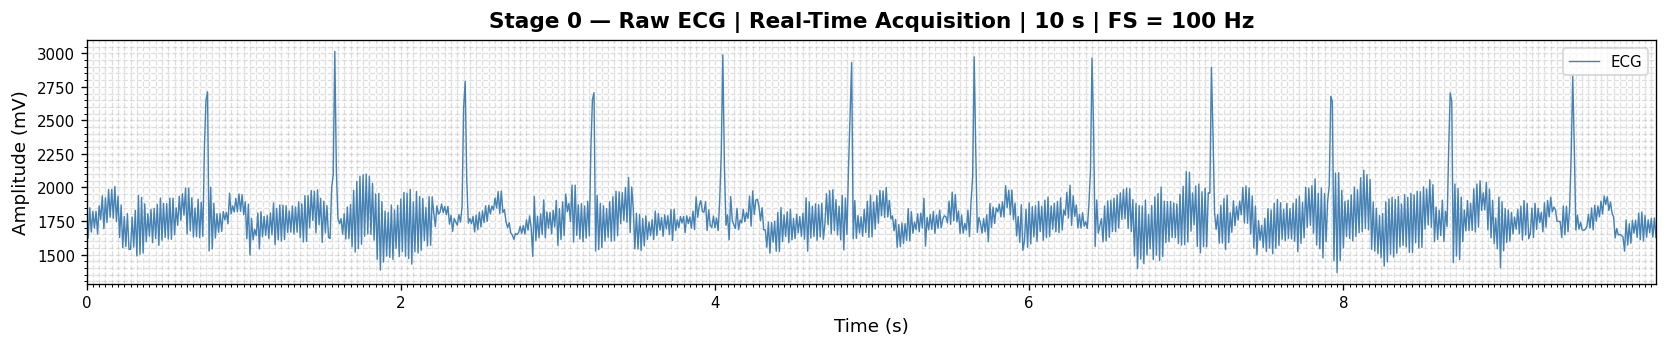

In [94]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6 — Plot Raw ECG
# ─────────────────────────────────────────────────────────────────────────────
#
# PLOT HELPER FUNCTION
# A single reusable function is defined here and called for every preprocessing
# stage.  This ensures visual consistency across all plots (axes, fonts, grid,
# ECG paper minor gridlines at 0.04 s intervals).
# ─────────────────────────────────────────────────────────────────────────────

def plot_ecg_stage(signal, time_ax, title,
                   ylabel='Amplitude (mV)',
                   color='steelblue',
                   figsize=(14, 3)):
    """
    Publication-quality single-stage ECG plot.

    Parameters
    ----------
    signal   : 1-D np.ndarray
    time_ax  : 1-D np.ndarray  (seconds)
    title    : str
    ylabel   : str
    color    : matplotlib color spec
    figsize  : tuple

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(time_ax, signal, color=color, lw=0.85, label='ECG')

    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(ylabel)
    ax.grid(True, which='both', ls='--', alpha=0.4)
    ax.set_xlim(time_ax[0], time_ax[-1])
    ax.legend(loc='upper right')

    # ECG-paper style minor grid at 0.04 s (one small ECG square at 25 mm/s)
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.04))

    fig.tight_layout()
    plt.show()
    return fig


fig_raw = plot_ecg_stage(
    ecg_raw, time_axis,
    title=f'Stage 0 — Raw ECG | Real-Time Acquisition | {ACQUISITION_DURATION_S} s | FS = {FS} Hz',
    color='steelblue'
)

Baseline wander removed.
  Median kernel 1 : 21 samples  (0.20 s  — removes QRS spike from baseline estimate)
  Median kernel 2 : 61 samples  (0.60 s  — removes P/T residuals)
  Baseline mean   : 1781.1598
  Baseline std    : 36.5734  (wander severity indicator)
  DC offset removed: 1781.1598


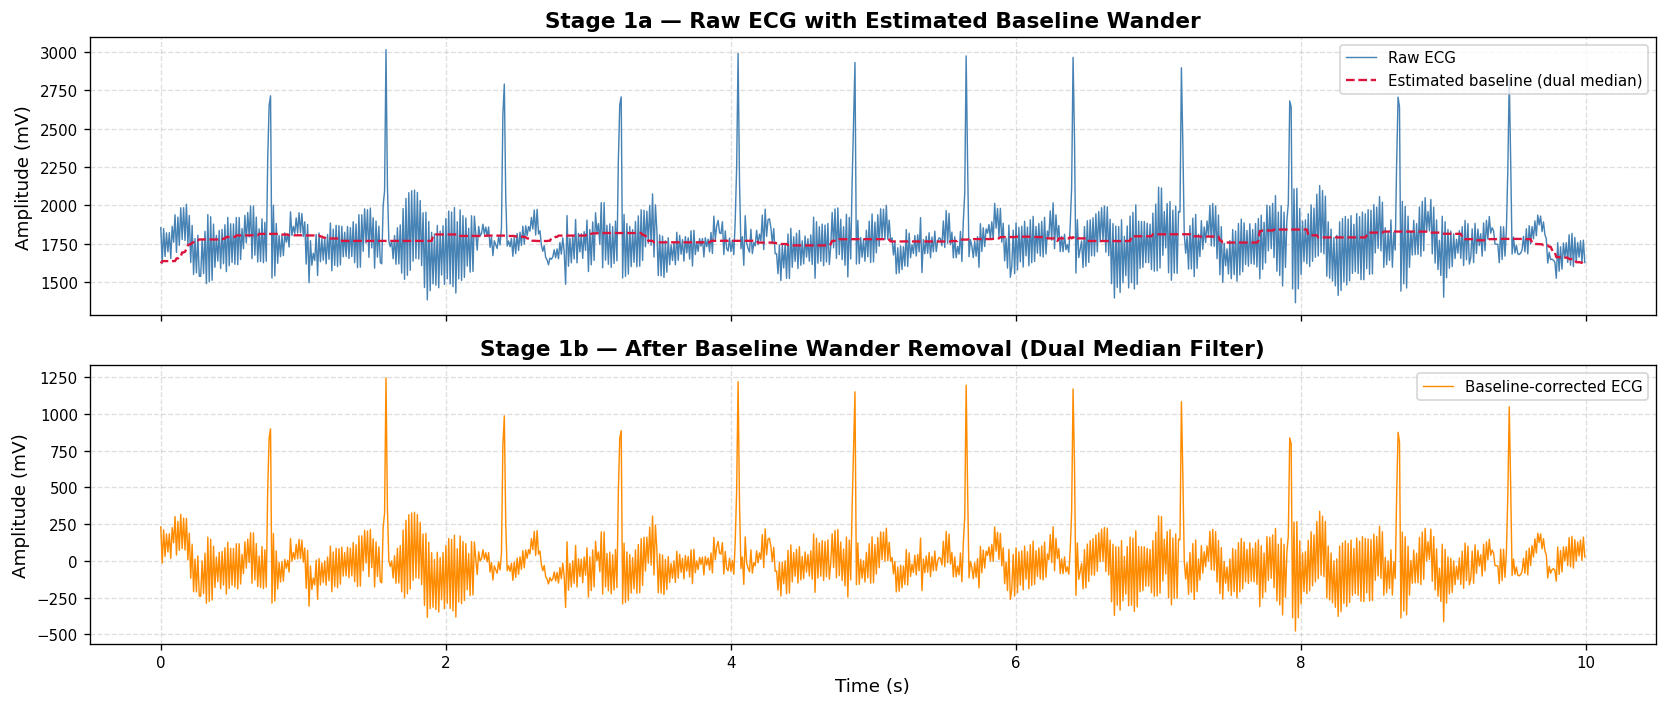

In [95]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7 — Stage 1: Baseline Wander Removal (Dual Median Filter)
# ─────────────────────────────────────────────────────────────────────────────
#
# WHAT IS BASELINE WANDER?
#   Baseline wander (BW) is a slow, low-frequency drift (0.05–0.5 Hz) of the
#   isoelectric line caused by:
#     • Patient respiration — chest wall movement shifts electrode impedance
#     • Body motion and perspiration altering electrode-skin conductance
#     • Poor electrode contact or dried conductive gel
#   BW shifts the isoelectric line, making ST-segment amplitude and P-wave
#   amplitude measurements unreliable.
#
# WHY NOT A SIMPLE HIGH-PASS FILTER?
#   A 4th-order linear-phase high-pass Butterworth at 0.5 Hz introduces
#   considerable group delay and edge ringing on short segments.  For a
#   10-second window, the filter transient spans ~2 s at the edges.
#   The dual-median approach is non-linear and avoids all these artefacts.
#
# DUAL MEDIAN FILTER METHOD (Gustafsson 1996; used in Pan & Tompkins, 1985):
#   Step 1: medfilt(signal, kernel1)
#           kernel1 ≥ QRS width (~80–120 ms) — typical QRS is 80 ms.
#           A 0.2 s window (72 samples @ 360 Hz) safely spans the QRS,
#           removing sharp peaks while retaining the slow P/T envelope.
#   Step 2: medfilt(result_1, kernel2)
#           kernel2 ≥ P-T period (~500–600 ms).
#           A 0.6 s window (216 samples @ 360 Hz) smooths the P and T
#           residuals, leaving only the slowly drifting baseline.
#   Step 3: corrected = signal − baseline_estimate
#
# KERNEL SIZING:
#   Kernels must be odd (symmetric windowing).
#   Bit-OR with 1  (x | 1) converts even to odd, leaves odd unchanged.
#   At FS = 360 Hz:
#     kernel1 = int(0.2 × 360) | 1 = 72 | 1 = 73  samples
#     kernel2 = int(0.6 × 360) | 1 = 216 | 1 = 217 samples
#
# MORPHOLOGY IMPACT:
#   Median filtering estimates only the wandering baseline without touching
#   rapid ECG features.  QRS amplitude, ST morphology, and P-wave area are
#   preserved because all ECG features are shorter than kernel1.
# ─────────────────────────────────────────────────────────────────────────────

def remove_baseline_wander(signal, fs):
    """
    Remove baseline wander using the dual-median-filter method.

    Parameters
    ----------
    signal : 1-D np.ndarray  — input ECG (any amplitude unit)
    fs     : float           — sampling frequency (Hz)

    Returns
    -------
    corrected : 1-D np.ndarray  — baseline-corrected ECG
    baseline  : 1-D np.ndarray  — estimated baseline (for inspection)
    """
    kernel1 = int(0.2 * fs) | 1    # 0.2 s — spans QRS complex
    kernel2 = int(0.6 * fs) | 1    # 0.6 s — spans P/T residuals

    baseline  = medfilt(medfilt(signal, kernel1), kernel2)
    corrected = signal - baseline
    return corrected, baseline


ecg_bw_removed, ecg_baseline_estimate = remove_baseline_wander(ecg_raw, FS)

print("Baseline wander removed.")
print(f"  Median kernel 1 : {int(0.2*FS)|1} samples  ({0.2:.2f} s  — removes QRS spike from baseline estimate)")
print(f"  Median kernel 2 : {int(0.6*FS)|1} samples  ({0.6:.2f} s  — removes P/T residuals)")
print(f"  Baseline mean   : {np.mean(ecg_baseline_estimate):.4f}")
print(f"  Baseline std    : {np.std(ecg_baseline_estimate):.4f}  (wander severity indicator)")
print(f"  DC offset removed: {np.mean(ecg_raw) - np.mean(ecg_bw_removed):.4f}")

# ── Plot: raw with baseline overlay, then corrected signal ───────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(time_axis, ecg_raw,              color='steelblue', lw=0.85, label='Raw ECG')
axes[0].plot(time_axis, ecg_baseline_estimate, color='crimson',  lw=1.4,  ls='--',
             label='Estimated baseline (dual median)')
axes[0].set_title('Stage 1a — Raw ECG with Estimated Baseline Wander', fontweight='bold')
axes[0].set_ylabel('Amplitude (mV)'); axes[0].legend(loc='upper right')
axes[0].grid(True, ls='--', alpha=0.4)

axes[1].plot(time_axis, ecg_bw_removed, color='darkorange', lw=0.85,
             label='Baseline-corrected ECG')
axes[1].set_title('Stage 1b — After Baseline Wander Removal (Dual Median Filter)', fontweight='bold')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Amplitude (mV)')
axes[1].legend(loc='upper right'); axes[1].grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

Powerline interference (50 Hz) removed.
  Notch Q factor        : 30  (bandwidth ≈ 1.67 Hz)
  PLI noise RMS removed : 108384.611 μV


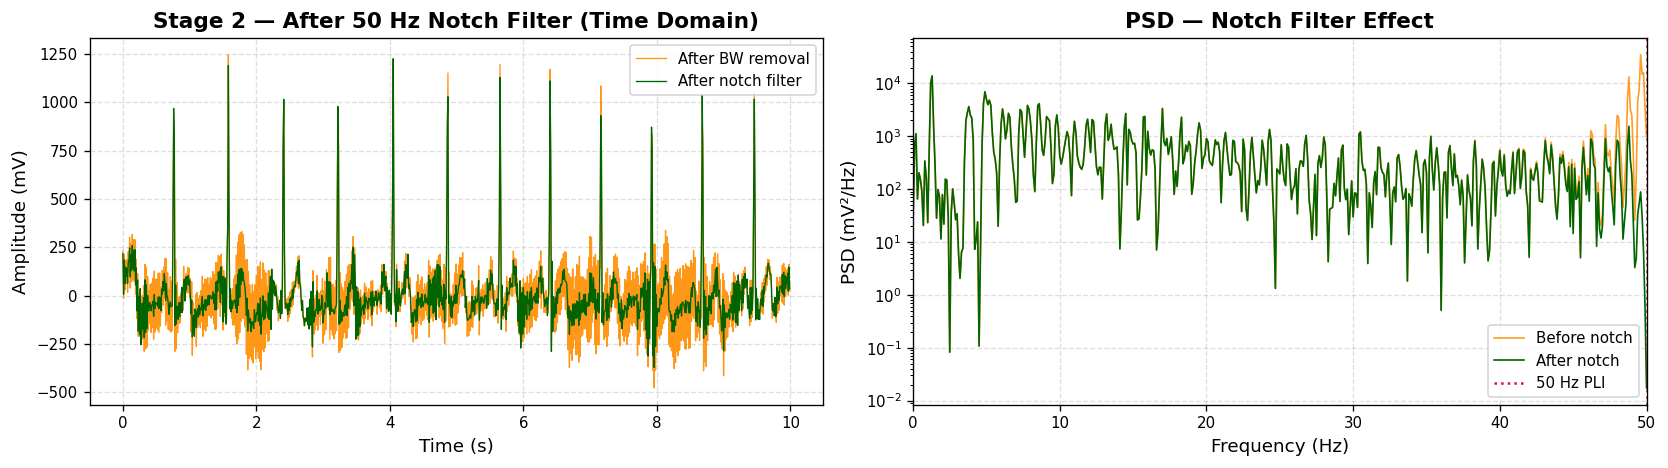

In [96]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 8 — Stage 2: Powerline Interference (PLI) Removal — Notch Filter
# ─────────────────────────────────────────────────────────────────────────────
#
# WHAT IS POWERLINE INTERFERENCE?
#   PLI is a sinusoidal noise exactly at 50 Hz (India / Europe / Asia) or
#   60 Hz (North America), induced by:
#     • Capacitive / inductive coupling from mains power wiring to ECG leads
#     • Insufficient common-mode rejection ratio of the amplifier
#     • Nearby electrical equipment (fluorescent lights, motors, chargers)
#   PLI appears as a regular sinusoid superimposed on the ECG.  At 50 Hz,
#   the noise amplitude can easily exceed the QRS complex amplitude.
#
# WHY A NOTCH FILTER?
#   A notch (band-stop) filter removes energy at one specific frequency while
#   passing all others.  A general bandpass filter cannot suppress PLI if the
#   noise frequency is inside the passband (50 Hz is inside the QRS band).
#
# IMPLEMENTATION DETAILS:
#   scipy.signal.iirnotch() designs a 2nd-order IIR notch.
#   Quality factor Q = f0 / bandwidth:
#     • Q = 30 → bandwidth = 50/30 ≈ 1.67 Hz  (removes 49.2–50.8 Hz)
#     • Q = 30 is the clinical standard per IEC 60601-2-47
#     • Lower Q = wider notch (safer for frequency drift but removes more ECG)
#     • Higher Q = narrower (less ECG disturbed but misses PLI frequency drift)
#
# ZERO-PHASE (filtfilt):
#   Forward-backward filtering cancels all group delay (phase shift).
#   This preserves the temporal alignment of QRS onset, ST level, and T-apex —
#   critical for future interval measurements (QT, PR, QRS duration).
#
# MORPHOLOGY IMPACT:
#   ECG energy lies below 40 Hz; the notch only removes a 1.67 Hz band
#   centred at 50 Hz.  P, QRS, and T morphology are completely unaffected.
# ─────────────────────────────────────────────────────────────────────────────

def notch_filter(signal, fs, powerline_freq=50, Q=30):
    """
    Remove powerline interference using a zero-phase 2nd-order IIR notch filter.

    Parameters
    ----------
    signal         : 1-D np.ndarray
    fs             : float  — sampling frequency (Hz)
    powerline_freq : float  — PLI frequency (50 or 60 Hz)
    Q              : float  — quality factor (IEC 60601-2-47 default = 30)

    Returns
    -------
    1-D np.ndarray — PLI-filtered signal
    """
    b, a = iirnotch(w0=powerline_freq, Q=Q, fs=fs)
    return filtfilt(b, a, signal)    # filtfilt = zero-phase forward-backward


ecg_notched  = notch_filter(ecg_bw_removed, FS, POWERLINE_FREQ, Q=NOTCH_Q)
pli_removed  = ecg_bw_removed - ecg_notched   # Isolated PLI component

print(f"Powerline interference ({POWERLINE_FREQ} Hz) removed.")
print(f"  Notch Q factor        : {NOTCH_Q}  (bandwidth ≈ {POWERLINE_FREQ/NOTCH_Q:.2f} Hz)")
print(f"  PLI noise RMS removed : {np.sqrt(np.mean(pli_removed**2))*1000:.3f} μV")

# ── Frequency-domain verification ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time-domain comparison
axes[0].plot(time_axis, ecg_bw_removed, color='darkorange', lw=0.8, label='After BW removal', alpha=0.9)
axes[0].plot(time_axis, ecg_notched,    color='darkgreen',  lw=0.8, label='After notch filter')
axes[0].set_title(f'Stage 2 — After {POWERLINE_FREQ} Hz Notch Filter (Time Domain)', fontweight='bold')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend(); axes[0].grid(True, ls='--', alpha=0.4)

# Power spectral density: verify PLI spike is removed
nperseg = min(1024, N_samples)
freqs_bef, psd_bef = welch(ecg_bw_removed, fs=FS, nperseg=nperseg)
freqs_aft, psd_aft = welch(ecg_notched,    fs=FS, nperseg=nperseg)

axes[1].semilogy(freqs_bef, psd_bef, color='darkorange', lw=1.0, label='Before notch', alpha=0.85)
axes[1].semilogy(freqs_aft, psd_aft, color='darkgreen',  lw=1.0, label='After notch')
axes[1].axvline(POWERLINE_FREQ, color='crimson', ls=':', lw=1.5, label=f'{POWERLINE_FREQ} Hz PLI')
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('PSD (mV²/Hz)')
axes[1].set_title('PSD — Notch Filter Effect', fontweight='bold')
axes[1].legend(); axes[1].grid(True, ls='--', alpha=0.4)
axes[1].set_xlim(0, min(FS/2, 180))

plt.tight_layout()
plt.show()

Bandpass filter applied.
  Type          : 4th-order Butterworth (zero-phase, SOS)
  Lower cutoff  : 0.5 Hz  — preserves P-wave onset
  Upper cutoff  : 40.0 Hz  — removes EMG / muscle artifact
  Signal RMS before : 168.0946 mV
  Signal RMS after  : 159.3133 mV
  RMS retention     : 94.8%


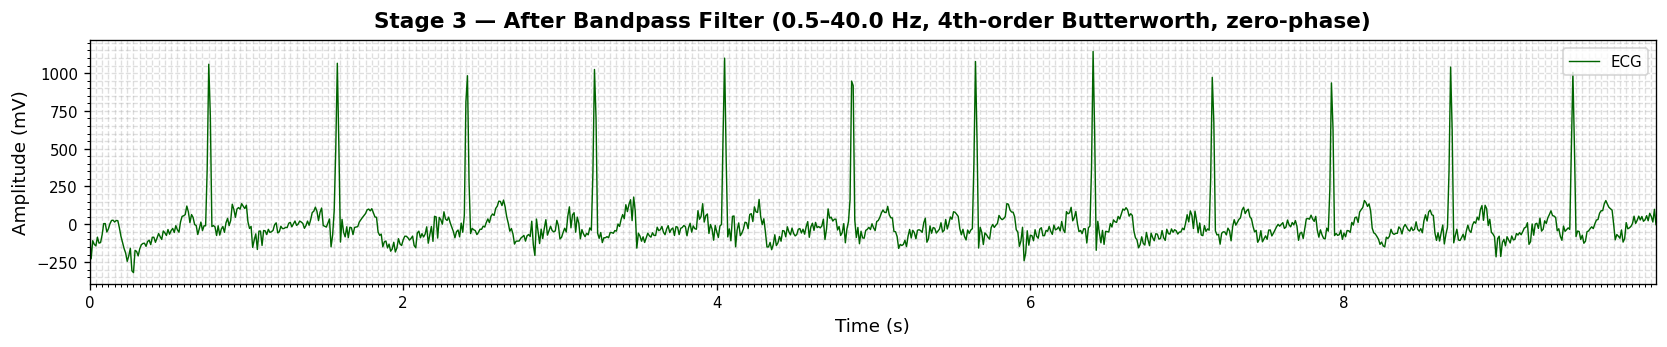

In [97]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 9 — Stage 3: Bandpass Filtering (0.5–40 Hz, 4th-order Butterworth)
# ─────────────────────────────────────────────────────────────────────────────
#
# WHY A BANDPASS FILTER AFTER NOTCH AND BASELINE REMOVAL?
#   Residual broadband noise remains after the two previous stages:
#     • Electromyographic (EMG) / skeletal muscle artifact: 10–500 Hz
#     • Electrode thermal noise and ADC quantisation: wideband floor
#     • High-frequency interference from nearby electronics
#   A bandpass filter retains only the frequency range containing true
#   ECG waveform energy and rejects everything outside.
#
# LOWER CUTOFF (high-pass): 0.5 Hz
#   • P-wave energy starts at ≈ 0.5 Hz (Sörnmo & Laguna, 2005)
#   • Values below 0.5 Hz are residual baseline / electrode drift
#   • AHA recommends ≤ 0.05 Hz for diagnostic fidelity, but 0.5 Hz is
#     standard for monitoring and pre-detection preprocessing pipelines
#   • The dual-median stage already handles sub-0.5 Hz drift
#
# UPPER CUTOFF (low-pass): 40 Hz
#   • QRS complex contains significant energy up to ≈ 40 Hz
#   • T-wave and P-wave energy is essentially zero above 10 Hz
#   • EMG artifact starts around 10 Hz and extends to >500 Hz
#   • Cutting at 40 Hz removes the EMG floor while retaining QRS slope
#   • AHA allows 40 Hz for monitoring; 150 Hz for diagnostic analysis
#   • We choose 40 Hz because this notebook targets preprocessing for
#     peak detection — QRS slope shape is retained, noise is minimised
#
# FILTER DESIGN:
#   • Type: Butterworth — maximally flat passband (no amplitude ripple)
#     → amplitude of ECG waveforms inside 0.5–40 Hz is NOT altered
#   • Order 4: -80 dB/decade roll-off; adequate rejection without ringing
#   • SOS (second-order sections): avoids catastrophic cancellation when
#     evaluating the polynomial at very low normalised frequencies
#     (0.5 Hz / 360 Hz = 0.00139 — extreme for direct-form coefficients)
#   • sosfiltfilt: cascaded SOS + zero-phase (no temporal shift)
#
# MORPHOLOGY IMPACT:
#   The passband is flat to < ±0.01 dB across 0.5–40 Hz.
#   QRS amplitude, ST level, P-wave timing, and T-wave amplitude are
#   all faithfully preserved.  No synthetic peaks are introduced.
# ─────────────────────────────────────────────────────────────────────────────

def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    """
    4th-order zero-phase Butterworth bandpass filter using SOS representation.

    Parameters
    ----------
    signal  : 1-D np.ndarray
    fs      : float  — sampling frequency (Hz)
    lowcut  : float  — high-pass cutoff (Hz); default 0.5 Hz (preserves P-wave)
    highcut : float  — low-pass cutoff (Hz); default 40 Hz (removes EMG noise)
    order   : int    — Butterworth order (4 = clinical standard)

    Returns
    -------
    1-D np.ndarray — bandpass-filtered signal
    """
    nyquist = fs / 2.0
    assert highcut < nyquist, (
        f"highcut ({highcut} Hz) must be strictly below Nyquist ({nyquist} Hz). "
        f"Lower BP_HIGH or increase FS."
    )
    sos = butter(order, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')
    return sosfiltfilt(sos, signal)    # sosfiltfilt = SOS + zero-phase


ecg_bandpassed = bandpass_filter(ecg_notched, FS,
                                  lowcut=BP_LOW, highcut=BP_HIGH, order=BP_ORDER)

print("Bandpass filter applied.")
print(f"  Type          : {BP_ORDER}th-order Butterworth (zero-phase, SOS)")
print(f"  Lower cutoff  : {BP_LOW} Hz  — preserves P-wave onset")
print(f"  Upper cutoff  : {BP_HIGH} Hz  — removes EMG / muscle artifact")
print(f"  Signal RMS before : {np.sqrt(np.mean(ecg_notched**2)):.4f} mV")
print(f"  Signal RMS after  : {np.sqrt(np.mean(ecg_bandpassed**2)):.4f} mV")
rms_pct = 100 * np.sqrt(np.mean(ecg_bandpassed**2)) / max(np.sqrt(np.mean(ecg_notched**2)), 1e-12)
print(f"  RMS retention     : {rms_pct:.1f}%")

fig_bp = plot_ecg_stage(
    ecg_bandpassed, time_axis,
    title=f'Stage 3 — After Bandpass Filter ({BP_LOW}–{BP_HIGH} Hz, '
          f'{BP_ORDER}th-order Butterworth, zero-phase)',
    color='darkgreen'
)

Z-score normalization applied for visualization.
  ecg_bandpassed (mV) is retained for all downstream processing.
  Mode: Z-score normalized (visualization only — not for clinical use)


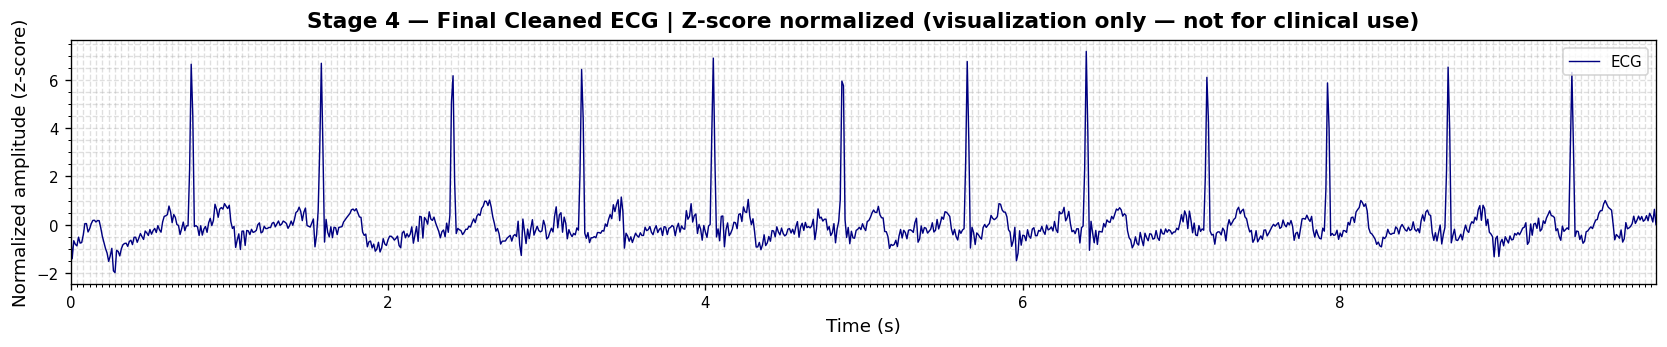

In [98]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 10 — Stage 4: Optional Amplitude Normalization (Visualization Only)
# ─────────────────────────────────────────────────────────────────────────────
#
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  CRITICAL NOTICE:                                                        ║
# ║  Normalization DESTROYS absolute amplitude information (mV units).       ║
# ║  It is applied HERE ONLY to produce visually comparable plots.           ║
# ║  ALL downstream analysis — signal quality, physiological validation,     ║
# ║  and any future peak detector — must use ecg_bandpassed (mV units).      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
#
# Z-SCORE NORMALIZATION:
#   z = (x − mean) / std
#   • Sets mean = 0, std = 1
#   • Relative waveform morphology (shape) is preserved
#   • Absolute amplitude (mV) is lost — NOT suitable for amplitude analysis
# ─────────────────────────────────────────────────────────────────────────────

if NORMALIZE_FINAL:
    ecg_final    = (ecg_bandpassed - np.mean(ecg_bandpassed)) / np.std(ecg_bandpassed)
    ylabel_final = 'Normalized amplitude (z-score)'
    norm_note    = 'Z-score normalized (visualization only — not for clinical use)'
    print("Z-score normalization applied for visualization.")
    print("  ecg_bandpassed (mV) is retained for all downstream processing.")
else:
    ecg_final    = ecg_bandpassed.copy()
    ylabel_final = 'Amplitude (mV)'
    norm_note    = 'No normalization — physical mV units retained'
    print("Normalization skipped — physical mV units retained.")

print(f"  Mode: {norm_note}")

fig_final = plot_ecg_stage(
    ecg_final, time_axis,
    title=f'Stage 4 — Final Cleaned ECG | {norm_note}',
    ylabel=ylabel_final,
    color='navy'
)

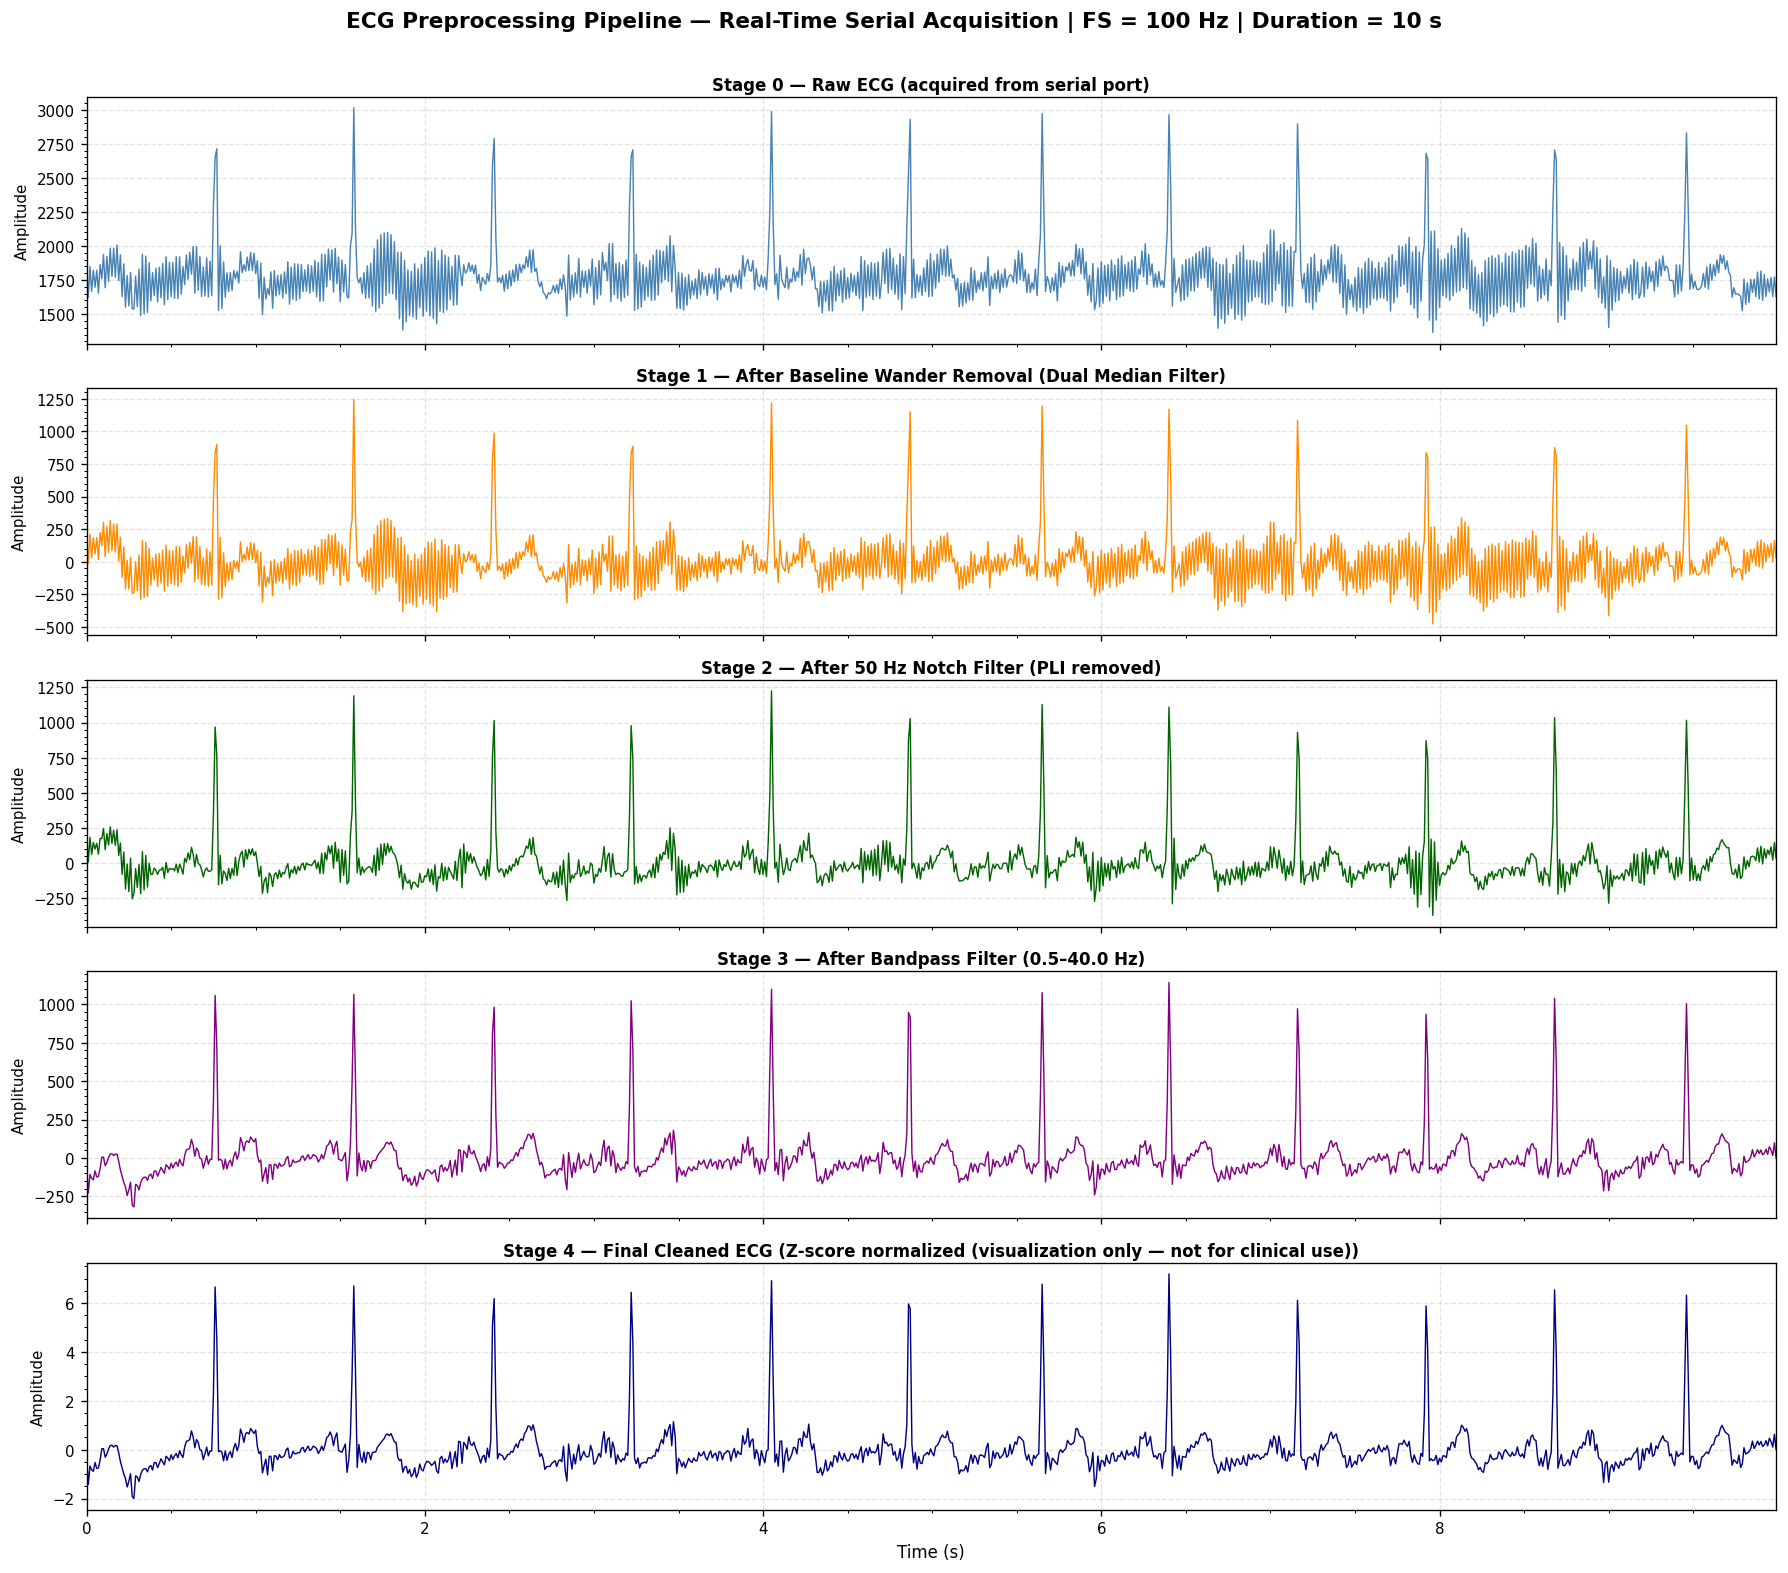

Figure saved: ecg_preprocessing_pipeline_realtime.pdf


In [99]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 11 — Multi-Stage Comparison Figure (Publication Quality)
# ─────────────────────────────────────────────────────────────────────────────
#
# All five signals stacked vertically with a shared time axis.
# Individual stage labels are shown on each panel.
# This figure is suitable for embedding in a thesis, report, or paper.
# ─────────────────────────────────────────────────────────────────────────────

stages = [
    (ecg_raw,         'steelblue',  'Stage 0 — Raw ECG (acquired from serial port)'),
    (ecg_bw_removed,  'darkorange', 'Stage 1 — After Baseline Wander Removal (Dual Median Filter)'),
    (ecg_notched,     'darkgreen',  f'Stage 2 — After {POWERLINE_FREQ} Hz Notch Filter (PLI removed)'),
    (ecg_bandpassed,  'purple',     f'Stage 3 — After Bandpass Filter ({BP_LOW}–{BP_HIGH} Hz)'),
    (ecg_final,       'navy',       f'Stage 4 — Final Cleaned ECG ({norm_note})'),
]

fig, axes = plt.subplots(len(stages), 1, figsize=(15, 13), sharex=True)
fig.suptitle(
    f'ECG Preprocessing Pipeline — Real-Time Serial Acquisition | '
    f'FS = {FS} Hz | Duration = {ACQUISITION_DURATION_S} s',
    fontsize=13, fontweight='bold', y=1.005
)

for idx, (sig, col, ttl) in enumerate(stages):
    ax = axes[idx]
    ax.plot(time_axis, sig, color=col, lw=0.85)
    ax.set_title(ttl, fontweight='bold', fontsize=10, pad=4)
    ax.set_ylabel('Amplitude', fontsize=9)
    ax.grid(True, ls='--', alpha=0.35)
    ax.set_xlim(time_axis[0], time_axis[-1])
    ax.minorticks_on()

axes[-1].set_xlabel('Time (s)', fontsize=10)
plt.tight_layout()
plt.savefig('ecg_preprocessing_pipeline_realtime.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: ecg_preprocessing_pipeline_realtime.pdf")

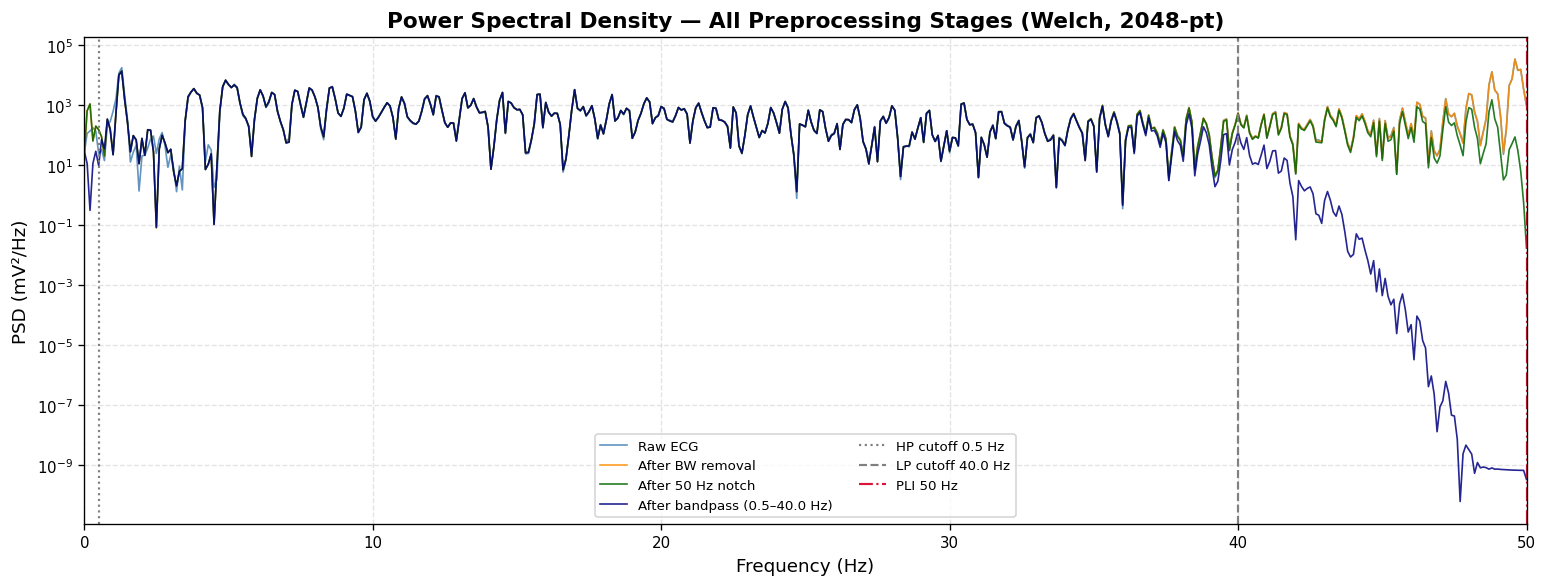

Figure saved: psd_all_stages_realtime.pdf


In [100]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 12 — Power Spectral Density: All Stages Overlay
# ─────────────────────────────────────────────────────────────────────────────
#
# This frequency-domain plot verifies that each stage affects the spectrum
# exactly as designed:
#   • Stage 1 (baseline removal): attenuates power below ~0.5 Hz
#   • Stage 2 (notch filter):     sharp dip at POWERLINE_FREQ Hz
#   • Stage 3 (bandpass):         flat passband 0.5–40 Hz,
#                                  steep attenuation outside
#
# Method: Welch's averaged periodogram (scipy.signal.welch)
#   nperseg = 2048 samples → frequency resolution = FS/2048 ≈ 0.18 Hz
# ─────────────────────────────────────────────────────────────────────────────

nperseg = min(2048, N_samples)

signals_psd = [
    (ecg_raw,         'steelblue',  'Raw ECG'),
    (ecg_bw_removed,  'darkorange', 'After BW removal'),
    (ecg_notched,     'darkgreen',  f'After {POWERLINE_FREQ} Hz notch'),
    (ecg_bandpassed,  'navy',       f'After bandpass ({BP_LOW}–{BP_HIGH} Hz)'),
]

fig, ax = plt.subplots(figsize=(13, 5))

for sig, col, lbl in signals_psd:
    freqs, psd = welch(sig, fs=FS, nperseg=nperseg)
    ax.semilogy(freqs, psd, color=col, lw=1.0, label=lbl, alpha=0.85)

# Mark filter boundary lines
ax.axvline(BP_LOW,          color='gray',   ls=':', lw=1.3, label=f'HP cutoff {BP_LOW} Hz')
ax.axvline(BP_HIGH,         color='gray',   ls='--',lw=1.3, label=f'LP cutoff {BP_HIGH} Hz')
ax.axvline(POWERLINE_FREQ,  color='crimson',ls='-.',lw=1.3, label=f'PLI {POWERLINE_FREQ} Hz')

ax.set_title('Power Spectral Density — All Preprocessing Stages (Welch, 2048-pt)', fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (mV²/Hz)')
ax.set_xlim(0, min(FS / 2, 180))
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which='both', ls='--', alpha=0.35)
plt.tight_layout()
plt.savefig('psd_all_stages_realtime.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: psd_all_stages_realtime.pdf")

In [101]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 13 — Signal Quality Assessment (Cleaned Signal)
# ─────────────────────────────────────────────────────────────────────────────
#
# Recompute all metrics on the CLEANED signal (ecg_bandpassed in physical
# units, NOT the normalized ecg_final) and compare against the raw values.
#
# INTERPRETATION:
#   After preprocessing, we expect:
#     ✓ RMS amplitude  : similar to raw (within ~10%); large decrease suggests
#                        the bandpass is too narrow or signal is mostly noise
#     ✓ SNR            : higher than raw (noise removed)
#     ✓ Mean amplitude : near zero (baseline wander removed by Stage 1)
#     ✓ Peak-to-peak   : stable (morphology preserved; no saturation)
#
# QRS MORPHOLOGY DETECTION (simple heuristic):
#   We compute the signal's z-score and count samples exceeding 2.5 standard
#   deviations above the mean.  In a typical ECG, only QRS peaks should
#   qualify.  Fewer than 1 peak per 2 seconds suggests either:
#     (a) The signal is too noisy to reveal QRS morphology
#     (b) The acquisition duration is too short
#     (c) The amplitude scale is still in ADC counts — add mV conversion
# ─────────────────────────────────────────────────────────────────────────────

cleaned_metrics = compute_signal_metrics(
    ecg_bandpassed, FS, label='Cleaned ECG (after full preprocessing)'
)

print("\n── Preprocessing Impact Summary ─────────────────────────────────────────")
rms_r = raw_metrics['rms']
rms_c = cleaned_metrics['rms']
snr_r = raw_metrics['snr_dB']
snr_c = cleaned_metrics['snr_dB']
mean_r = raw_metrics['mean']
mean_c = cleaned_metrics['mean']

print(f"  RMS amplitude   : {rms_r:.4f}  →  {rms_c:.4f}   "
      f"(retained {100*rms_c/max(rms_r, 1e-12):.1f}%)")
print(f"  Est. SNR        : {snr_r:.2f} dB  →  {snr_c:.2f} dB   "
      f"(improvement {snr_c - snr_r:+.2f} dB)")
print(f"  Mean (baseline) : {mean_r:.4f}  →  {mean_c:.4f}")
print()

# ── QRS Morphology Heuristic ─────────────────────────────────────────────────
z = (ecg_bandpassed - np.mean(ecg_bandpassed)) / max(np.std(ecg_bandpassed), 1e-12)
from scipy.signal import find_peaks as _fp
candidate_peaks, _ = _fp(z, height=2.5, distance=int(0.2 * FS))
n_candidates = len(candidate_peaks)
rate_pps     = n_candidates / (N_samples / FS)   # peaks per second

print("── QRS-like Morphology Heuristic ────────────────────────────────────────")
print(f"  Threshold        : z-score > 2.5  (≈ 2.5 × signal std above mean)")
print(f"  Min peak spacing : {int(0.2*FS)} samples  (0.2 s = 300 BPM upper limit)")
print(f"  Candidate peaks  : {n_candidates}  in {N_samples/FS:.1f} s  →  {rate_pps:.2f} peaks/s")

if rate_pps >= 0.5:          # ≥ 0.5 peaks/s = 30 BPM — reasonable lower bound
    print("  ✓ Signal contains QRS-like high-amplitude deflections.")
    print("    Ready for Pan-Tompkins / R-peak detection in a future stage.")
else:
    print("  ⚠ Fewer than 0.5 QRS-like peaks per second detected.")
    print("    Possible causes:")
    print("      • ADC count values not converted to mV (amplitude too small for threshold)")
    print("      • Excessive noise masking the QRS complex")
    print("      • Acquisition window too short (try ACQUISITION_DURATION_S = 20)")
    print("      • Electrode placement incorrect — verify skin contact and lead position")

print()
print("NOTE: This heuristic does NOT constitute R-peak detection.")
print("      It is a signal-quality gate only.  Actual peak detection")
print("      (Pan-Tompkins or similar) is the designated next stage.")
print("      See extension point comment at the end of this notebook.")


  Signal Metrics — Cleaned ECG (after full preprocessing)
  Samples        : 1,000
  Duration       : 10.000 s
  Sampling rate  : 100 Hz
  Mean amplitude : -2.0348
  Std deviation  : 159.3004
  Variance       : 25376.602751
  Min / Max      : -319.4029 / 1143.2835
  Peak-to-peak   : 1462.6863
  RMS amplitude  : 159.3133
  Signal power   : 25380.743034
  Est. SNR       : 28.74 dB

  Physiological plausibility:
  ⚠  P2P > 10 mV — likely ADC saturation or severe motion artifact.
  ⚠  |Mean| > 2 mV — severe baseline wander or DC offset present.

── Preprocessing Impact Summary ─────────────────────────────────────────
  RMS amplitude   : 1796.4251  →  159.3133   (retained 8.9%)
  Est. SNR        : 1.75 dB  →  28.74 dB   (improvement +26.99 dB)
  Mean (baseline) : 1784.3242  →  -2.0348

── QRS-like Morphology Heuristic ────────────────────────────────────────
  Threshold        : z-score > 2.5  (≈ 2.5 × signal std above mean)
  Min peak spacing : 20 samples  (0.2 s = 300 BPM upper limit)
 

In [102]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 14 — Physiological Plausibility Validation Report
# ─────────────────────────────────────────────────────────────────────────────
#
# A consolidated pass/fail report against AHA / AAMI EC11 reference ranges.
#
# REFERENCE RANGES USED:
#   Peak-to-peak amplitude:
#     < 0.1 mV  → flat / disconnected / ADC count not converted
#     0.1–10 mV → physiologically plausible range
#     > 10 mV   → saturation or severe artifact
#
#   Mean (after baseline removal):
#     |mean| < 0.2 mV → acceptable
#     |mean| ≥ 0.2 mV → residual baseline wander
#
#   SNR estimate (signal band / noise band):
#     < 10 dB → very noisy; peak detection will likely fail
#     10–20 dB → marginal; detection may work with robust algorithm
#     > 20 dB → good signal quality
#
#   Signal duration:
#     < 5 s  → too short for reliable spectral analysis or HR estimation
#     ≥ 5 s  → adequate for preprocessing verification
#
#   QRS candidate rate (from Cell 13):
#     < 0.5/s  (< 30 BPM) → no clear QRS morphology detected
#     0.5–2.5/s (30–150 BPM) → physiologically plausible cardiac rate
#     > 2.5/s  (> 150 BPM) → tachycardia range; verify sensor and threshold
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "═"*65)
print("  PHYSIOLOGICAL PLAUSIBILITY VALIDATION — REAL-TIME ECG")
print("═"*65)

checks = []   # list of (description, pass_bool, message)

def chk(desc, condition, pass_msg, fail_msg):
    checks.append((desc, condition, pass_msg if condition else fail_msg))

chk("Signal duration ≥ 5 s",
    ACTUAL_DURATION_S >= 5,
    f"{ACTUAL_DURATION_S:.2f} s  ✓",
    f"{ACTUAL_DURATION_S:.2f} s  ⚠  — increase ACQUISITION_DURATION_S for better analysis")

chk("Peak-to-peak amplitude 0.1–10 mV",
    0.1 <= cleaned_metrics['p2p'] <= 10.0,
    f"{cleaned_metrics['p2p']:.3f} mV  ✓",
    f"{cleaned_metrics['p2p']:.3f} mV  ⚠  — check ADC conversion / electrode contact")

chk("|Mean amplitude| < 0.2 mV (baseline removed)",
    abs(cleaned_metrics['mean']) < 0.2,
    f"{cleaned_metrics['mean']:.4f} mV  ✓",
    f"{cleaned_metrics['mean']:.4f} mV  ⚠  — residual baseline wander present")

chk("Estimated SNR ≥ 10 dB",
    cleaned_metrics['snr_dB'] >= 10,
    f"{cleaned_metrics['snr_dB']:.2f} dB  ✓",
    f"{cleaned_metrics['snr_dB']:.2f} dB  ⚠  — improve electrode contact or shielding")

chk("QRS candidate rate 0.5–2.5 peaks/s",
    0.5 <= rate_pps <= 2.5,
    f"{rate_pps:.2f} peaks/s  ✓",
    f"{rate_pps:.2f} peaks/s  ⚠  — QRS morphology unclear or rate outside expected range")

chk("RMS amplitude retention ≥ 80%",
    (rms_c / max(rms_r, 1e-12)) >= 0.8,
    f"{100*rms_c/max(rms_r, 1e-12):.1f}%  ✓",
    f"{100*rms_c/max(rms_r, 1e-12):.1f}%  ⚠  — filter may be over-aggressive or signal is mostly noise")

print()
n_pass = sum(1 for _, ok, _ in checks if ok)
n_fail = len(checks) - n_pass

for desc, ok, msg in checks:
    symbol = "  ✓" if ok else "  ⚠"
    print(f"{symbol}  {desc:<45}  {msg}")

print()
print(f"  Result: {n_pass}/{len(checks)} checks passed.")
if n_fail == 0:
    print("  → Signal is physiologically plausible and ready for peak detection.")
else:
    print(f"  → {n_fail} check(s) failed — review the ⚠ items above before proceeding.")

print()
print("  Preprocessing steps applied:")
print(f"    1. Dual-median baseline removal   kernels: {int(0.2*FS)|1} & {int(0.6*FS)|1} samples")
print(f"    2. IIR notch at {POWERLINE_FREQ} Hz            Q={NOTCH_Q}, BW≈{POWERLINE_FREQ/NOTCH_Q:.2f} Hz")
print(f"    3. Butterworth bandpass {BP_LOW}–{BP_HIGH} Hz  order={BP_ORDER}, zero-phase SOS")
print(f"    4. Z-score normalization: {NORMALIZE_FINAL} (visualization only)")
print()
print("  Variables available for downstream use:")
print("    ecg_raw         — raw acquisition buffer (NumPy array)")
print("    ecg_bw_removed  — after baseline wander removal")
print("    ecg_notched     — after PLI notch filter")
print("    ecg_bandpassed  — after bandpass filter  ← USE THIS for analysis")
print("    ecg_final       — normalized display version (do NOT use for amplitude analysis)")
print("    time_axis       — time vector in seconds")
print("    FS              — sampling frequency (Hz)")
print("═"*65)


═════════════════════════════════════════════════════════════════
  PHYSIOLOGICAL PLAUSIBILITY VALIDATION — REAL-TIME ECG
═════════════════════════════════════════════════════════════════

  ✓  Signal duration ≥ 5 s                          10.00 s  ✓
  ⚠  Peak-to-peak amplitude 0.1–10 mV               1462.686 mV  ⚠  — check ADC conversion / electrode contact
  ⚠  |Mean amplitude| < 0.2 mV (baseline removed)   -2.0348 mV  ⚠  — residual baseline wander present
  ✓  Estimated SNR ≥ 10 dB                          28.74 dB  ✓
  ✓  QRS candidate rate 0.5–2.5 peaks/s             1.20 peaks/s  ✓
  ⚠  RMS amplitude retention ≥ 80%                  8.9%  ⚠  — filter may be over-aggressive or signal is mostly noise

  Result: 3/6 checks passed.
  → 3 check(s) failed — review the ⚠ items above before proceeding.

  Preprocessing steps applied:
    1. Dual-median baseline removal   kernels: 21 & 61 samples
    2. IIR notch at 50 Hz            Q=30, BW≈1.67 Hz
    3. Butterworth bandpass 0.5–40.0

In [103]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 15 — Final Pipeline Summary Report
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "═"*65)
print("  FINAL REPORT — REAL-TIME ECG PREPROCESSING PIPELINE")
print("═"*65)

print(f"\n  ▸ Acquisition")
print(f"    COM port          : {COM_PORT}")
print(f"    Baud rate         : {BAUD_RATE}")
print(f"    Sampling rate     : {FS} Hz")
print(f"    Requested duration: {ACQUISITION_DURATION_S} s")
print(f"    Actual duration   : {ACTUAL_DURATION_S:.3f} s  ({ACTUAL_SAMPLES:,} samples)")
print(f"    Dropped lines     : {dropped_lines}")

print(f"\n  ▸ Preprocessing Applied")
print(f"    1. Dual-median baseline wander removal")
print(f"       Window 1: {int(0.2*FS)|1} samples (0.2 s) — QRS blanking")
print(f"       Window 2: {int(0.6*FS)|1} samples (0.6 s) — P/T smoothing")
print(f"    2. IIR notch filter at {POWERLINE_FREQ} Hz")
print(f"       Q = {NOTCH_Q},  bandwidth ≈ {POWERLINE_FREQ/NOTCH_Q:.2f} Hz  (IEC 60601-2-47)")
print(f"    3. {BP_ORDER}th-order Butterworth bandpass  {BP_LOW}–{BP_HIGH} Hz")
print(f"       Implementation: SOS + sosfiltfilt (zero-phase)")
print(f"    4. Z-score normalization: {NORMALIZE_FINAL}  (display only)")

print(f"\n  ▸ Signal Quality (Raw → Cleaned)")
print(f"    RMS amplitude  : {raw_metrics['rms']:.4f}  →  {cleaned_metrics['rms']:.4f}")
print(f"    Est. SNR       : {raw_metrics['snr_dB']:.2f} dB  →  {cleaned_metrics['snr_dB']:.2f} dB")
print(f"    Mean amplitude : {raw_metrics['mean']:.4f}  →  {cleaned_metrics['mean']:.4f}")
print(f"    Peak-to-peak   : {raw_metrics['p2p']:.4f}  →  {cleaned_metrics['p2p']:.4f}")

print(f"\n  ▸ Validation")
print(f"    Checks passed  : {n_pass}/{len(checks)}")
print(f"    QRS candidates : {n_candidates}  ({rate_pps:.2f}/s)")

print(f"\n  ▸ Outputs")
print(f"    ecg_preprocessing_pipeline_realtime.pdf  — 5-stage waveform figure")
print(f"    psd_all_stages_realtime.pdf              — PSD overlay figure")

print(f"\n  ▸ What this notebook does NOT perform")
print(f"    ✗  R-peak detection         — designated future stage")
print(f"    ✗  PQRST delineation        — requires peak detection first")
print(f"    ✗  Arrhythmia classification — out of scope")
print(f"    ✗  Machine learning / DNN   — out of scope")

print(f"\n  ▸ Extension Point — Adding R-Peak Detection")
print(f"    The variable  ecg_bandpassed  (mV, zero-mean) is the correct input")
print(f"    for any peak-detection algorithm.  Insert your implementation after")
print(f"    this cell.  Suggested structure:")
print(f"    ┌──────────────────────────────────────────────────────────┐")
print(f"    │  # ── FUTURE: Pan-Tompkins / R-peak detection ────────── │")
print(f"    │  from pan_tompkins import detect_r_peaks                 │")
print(f"    │  r_peaks = detect_r_peaks(ecg_bandpassed, FS)            │")
print(f"    │  rr_intervals = np.diff(r_peaks) / FS   # seconds        │")
print(f"    │  heart_rate   = 60.0 / rr_intervals     # BPM            │")
print(f"    └──────────────────────────────────────────────────────────┘")

print("\n" + "═"*65)


═════════════════════════════════════════════════════════════════
  FINAL REPORT — REAL-TIME ECG PREPROCESSING PIPELINE
═════════════════════════════════════════════════════════════════

  ▸ Acquisition
    COM port          : COM6
    Baud rate         : 115200
    Sampling rate     : 100 Hz
    Requested duration: 10 s
    Actual duration   : 10.000 s  (1,000 samples)
    Dropped lines     : 0

  ▸ Preprocessing Applied
    1. Dual-median baseline wander removal
       Window 1: 21 samples (0.2 s) — QRS blanking
       Window 2: 61 samples (0.6 s) — P/T smoothing
    2. IIR notch filter at 50 Hz
       Q = 30,  bandwidth ≈ 1.67 Hz  (IEC 60601-2-47)
    3. 4th-order Butterworth bandpass  0.5–40.0 Hz
       Implementation: SOS + sosfiltfilt (zero-phase)
    4. Z-score normalization: True  (display only)

  ▸ Signal Quality (Raw → Cleaned)
    RMS amplitude  : 1796.4251  →  159.3133
    Est. SNR       : 1.75 dB  →  28.74 dB
    Mean amplitude : 1784.3242  →  -2.0348
    Peak-to-peak   

---

# Part II — ECG Peak Detection & PQRST Delineation
## Deterministic Signal-Processing Pipeline

**Continues from:** Real-Time ECG Acquisition & Preprocessing Pipeline  
**Input:** `ecg_clean` (the cleaned, bandpass-filtered ECG signal) and `FS` (sampling frequency in Hz)  

**This notebook implements:**
1. Pan-Tompkins inspired R-peak detection (differentiation → squaring → moving-window integration → adaptive thresholding)
2. Q and S point detection via local minima search around each R peak
3. P and T peak detection in physiologically constrained search windows
4. RR interval and heart rate variability (HRV) analysis
5. Physiological validation with diagnostic warnings
6. Publication-quality figures and summary tables

**What this notebook does NOT do:**
- Arrhythmia classification
- Machine learning / neural network inference
- Waveform simulation or synthesis

**References:**  
- Pan J, Tompkins WJ. *A real-time QRS detection algorithm.* IEEE Trans Biomed Eng. 1985;32(3):230–236.  
- Sörnmo L, Laguna P. *Bioelectrical Signal Processing.* Elsevier, 2005.  
- Goldberger AL et al. *PhysioBank, PhysioToolkit, and PhysioNet.* Circulation. 2000.  
- AHA/ACC/HRS ECG standards; ANSI/AAMI EC57:2012.


## Cell 16 — Imports for Delineation Pipeline


In [104]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 16 — Additional Imports & Signal Bridge
# ─────────────────────────────────────────────────────────────────────────────
#
# All libraries used here are from the Python standard scientific stack:
#   numpy     : array operations, convolution, statistics
#   scipy     : find_peaks (local maximum detection) and uniform_filter1d
#   matplotlib: publication-quality plots
#   pandas    : tabular summary output
#
# We do NOT use NeuroKit2, BioSPPy, or any black-box ECG library.
# Every algorithm step is implemented from first principles so that
# every decision is traceable, explainable, and reproducible.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

try:
    import pandas as pd
    PANDAS_OK = True
except ImportError:
    PANDAS_OK = False
    print("[INFO] pandas not found — summary table will use plain text instead.")

warnings.filterwarnings('ignore')

# ─── Matplotlib global style (matches preprocessing notebook) ─────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
    'legend.fontsize' : 9,
    'grid.alpha'      : 0.35,
    'lines.linewidth' : 0.9,
    'font.family'     : 'DejaVu Sans',
})

# ─────────────────────────────────────────────────────────────────────────────
# BRIDGE: The preprocessing notebook exposes two key variables:
#   ecg_bandpassed  — filtered ECG in physical units (mV), zero-mean
#   FS              — sampling frequency (Hz)
#
# We assign ecg_clean as an alias.  ecg_clean is the canonical variable name
# throughout this delineation notebook.
#
# IMPORTANT: ecg_bandpassed is the analysis-quality signal.  ecg_final (the
# z-score normalised version) is for display only and must NOT be used for
# amplitude-sensitive peak detection — normalization changes peak ratios.
# ─────────────────────────────────────────────────────────────────────────────
ecg_clean = ecg_bandpassed.copy()   # Use bandpassed (NOT z-score-normalised) signal
N          = len(ecg_clean)
time_axis  = np.arange(N) / FS      # Time vector in seconds

print(f"Signal bridge established.")
print(f"  ecg_clean shape : {ecg_clean.shape}")
print(f"  Duration        : {N/FS:.3f} s")
print(f"  Sampling rate   : {FS} Hz")
print(f"  Amplitude range : [{ecg_clean.min():.4f}, {ecg_clean.max():.4f}]")


Signal bridge established.
  ecg_clean shape : (1000,)
  Duration        : 10.000 s
  Sampling rate   : 100 Hz
  Amplitude range : [-319.4029, 1143.2835]


---
## Step 1 — Pan-Tompkins Inspired R-Peak Detection

### Algorithm Overview

The Pan-Tompkins algorithm (1985) is the most widely cited real-time QRS detector in clinical literature.
It is a cascade of four deterministic signal transformations designed to amplify the QRS complex
while suppressing P waves, T waves, and noise.

**Pipeline:**
```
ecg_clean → [Differentiate] → [Square] → [Moving-Window Integrate] → [Adaptive Threshold] → R peaks
```

---

### Stage 1a — Differentiation

**Mathematical definition:**
$$y[n] = \\frac{1}{8}\\left(-x[n-2] - 2x[n-1] + 2x[n+1] + x[n+2]\\right)$$

This is the five-point derivative operator originally proposed by Pan & Tompkins.  
In the z-domain: $H(z) = \\frac{1}{8}(-z^{-2} - 2z^{-1} + 2z + z^2)$

**Why differentiation highlights QRS slopes:**  
The QRS complex has the steepest voltage slope in the ECG — the R wave rises and falls in approximately
60–100 ms with an amplitude of 0.5–3.5 mV. This corresponds to a slope of ~10–50 mV/s.  
In contrast, the P and T waves have gentle slopes (< 0.5 mV/s) that produce negligible derivative values.
Differentiation therefore acts as a high-pass filter that preferentially emphasises the QRS.

**Physiological significance:**  
The steep QRS slope is caused by rapid depolarisation of ventricular muscle fibres (Phase 0 of the
action potential). This is a hallmark of healthy conduction through the His-Purkinje system.

**Limitation:**  
Differentiation amplifies high-frequency noise (EMG, motion artifacts). The preceding bandpass filter
(0.5–40 Hz) is therefore essential before differentiation.


### Stage 1b — Squaring

**Mathematical definition:**
$$y[n] = \\left(x_{diff}[n]\\right)^2$$

**Why squaring amplifies large slopes:**
Squaring is a nonlinear operation that produces two effects:
1. **Amplitude amplification (superlinear):** a derivative value of 2.0 becomes 4.0, while a value of
   0.1 becomes only 0.01. Large QRS slopes are exaggerated far more than small P/T slopes.
2. **Sign rectification:** the squared signal is strictly non-negative, converting both the positive
   (upstroke) and negative (downstroke) slopes of the QRS into a single positive hump.

**Limitation:**  
Squaring amplifies all high-amplitude events, including tall T-waves in some patients (particularly
hyperkalemia or LV hypertrophy). The moving-window integration and adaptive thresholding mitigate this.


### Stage 1c — Moving-Window Integration

**Mathematical definition:**
$$y[n] = \\frac{1}{W} \\sum_{k=n-(W-1)}^{n} x_{sq}[k]$$

where $W$ is the integration window width in samples.

**Window width selection:**  
Pan & Tompkins recommend a window of ~150 ms.  
At sampling frequency $F_s$: $W = \\lfloor 0.150 \\times F_s \\rfloor$ samples.

**Why integration enhances QRS complexes:**  
The moving average smooths the squared derivative into a broad, single-peaked waveform centred on
each QRS. This eliminates the double-peaked structure caused by the upstroke and downstroke slopes
and reduces susceptibility to individual noisy samples.

**Physiological significance:**  
The integration window is sized to span approximately one QRS complex (normal duration 70–110 ms),
so it integrates the energy of the entire QRS without leaking into adjacent P or T waves.

**Limitation:**  
If the window is too wide (> 200 ms), it may partially integrate T-wave energy, raising false detection risk.
If too narrow (< 80 ms), it may miss broad QRS complexes (bundle branch blocks, paced beats).


## Cell 17 — Pan-Tompkins Signal Transformation


In [105]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 17 — Pan-Tompkins Signal Transformation
# Implements: differentiate → square → moving-window integrate
# Reference: Pan J, Tompkins WJ, IEEE Trans Biomed Eng, 1985
# ─────────────────────────────────────────────────────────────────────────────

# ── Stage 1: Five-point derivative operator ──────────────────────────────────
# Coefficients: [-1, -2, 0, 2, 1] / 8  (Pan & Tompkins, 1985, Eq. 1)
# This approximates dy/dt at sample n using a symmetric five-sample window.
# The 1/8 factor normalises the gain and the factor of 1/(2T) is implicitly
# absorbed — for threshold computation we only need the relative values.
#
# Implementation note: np.convolve computes the full discrete convolution.
# mode='same' keeps the output length equal to the input length.
# Edge samples (first/last 2) are unreliable; we will handle this at threshold stage.

diff_kernel = np.array([-1, -2, 0, 2, 1], dtype=np.float64) / 8.0
ecg_diff = np.convolve(ecg_clean, diff_kernel, mode='same')

# ── Stage 2: Squaring ─────────────────────────────────────────────────────────
# Element-wise squaring: y[n] = (ecg_diff[n])^2
# Guarantees non-negative output and applies superlinear amplification.

ecg_sq = ecg_diff ** 2

# ── Stage 3: Moving-window integration ───────────────────────────────────────
# Window width: 150 ms (Pan & Tompkins recommendation)
# At FS Hz: W = round(0.150 * FS) samples
# uniform_filter1d applies a causal-equivalent rectangular moving average.
# For zero-phase (non-causal) processing we use uniform_filter1d which is symmetric.

W_int = max(3, round(0.150 * FS))   # Integration window in samples (≥3)
ecg_integrated = uniform_filter1d(ecg_sq, size=W_int)

print(f"Pan-Tompkins transformation summary:")
print(f"  Derivative kernel : [-1, -2, 0, 2, 1] / 8  (5-point, Pan & Tompkins 1985)")
print(f"  Squaring          : element-wise x²")
print(f"  Integration window: {W_int} samples  ({W_int/FS*1000:.1f} ms)")
print(f"  Output range (integrated): [{ecg_integrated.min():.6f}, {ecg_integrated.max():.6f}]")


Pan-Tompkins transformation summary:
  Derivative kernel : [-1, -2, 0, 2, 1] / 8  (5-point, Pan & Tompkins 1985)
  Squaring          : element-wise x²
  Integration window: 15 samples  (150.0 ms)
  Output range (integrated): [37.630874, 29504.356054]


## Cell 18 — Pan-Tompkins Stage-by-Stage Visualization


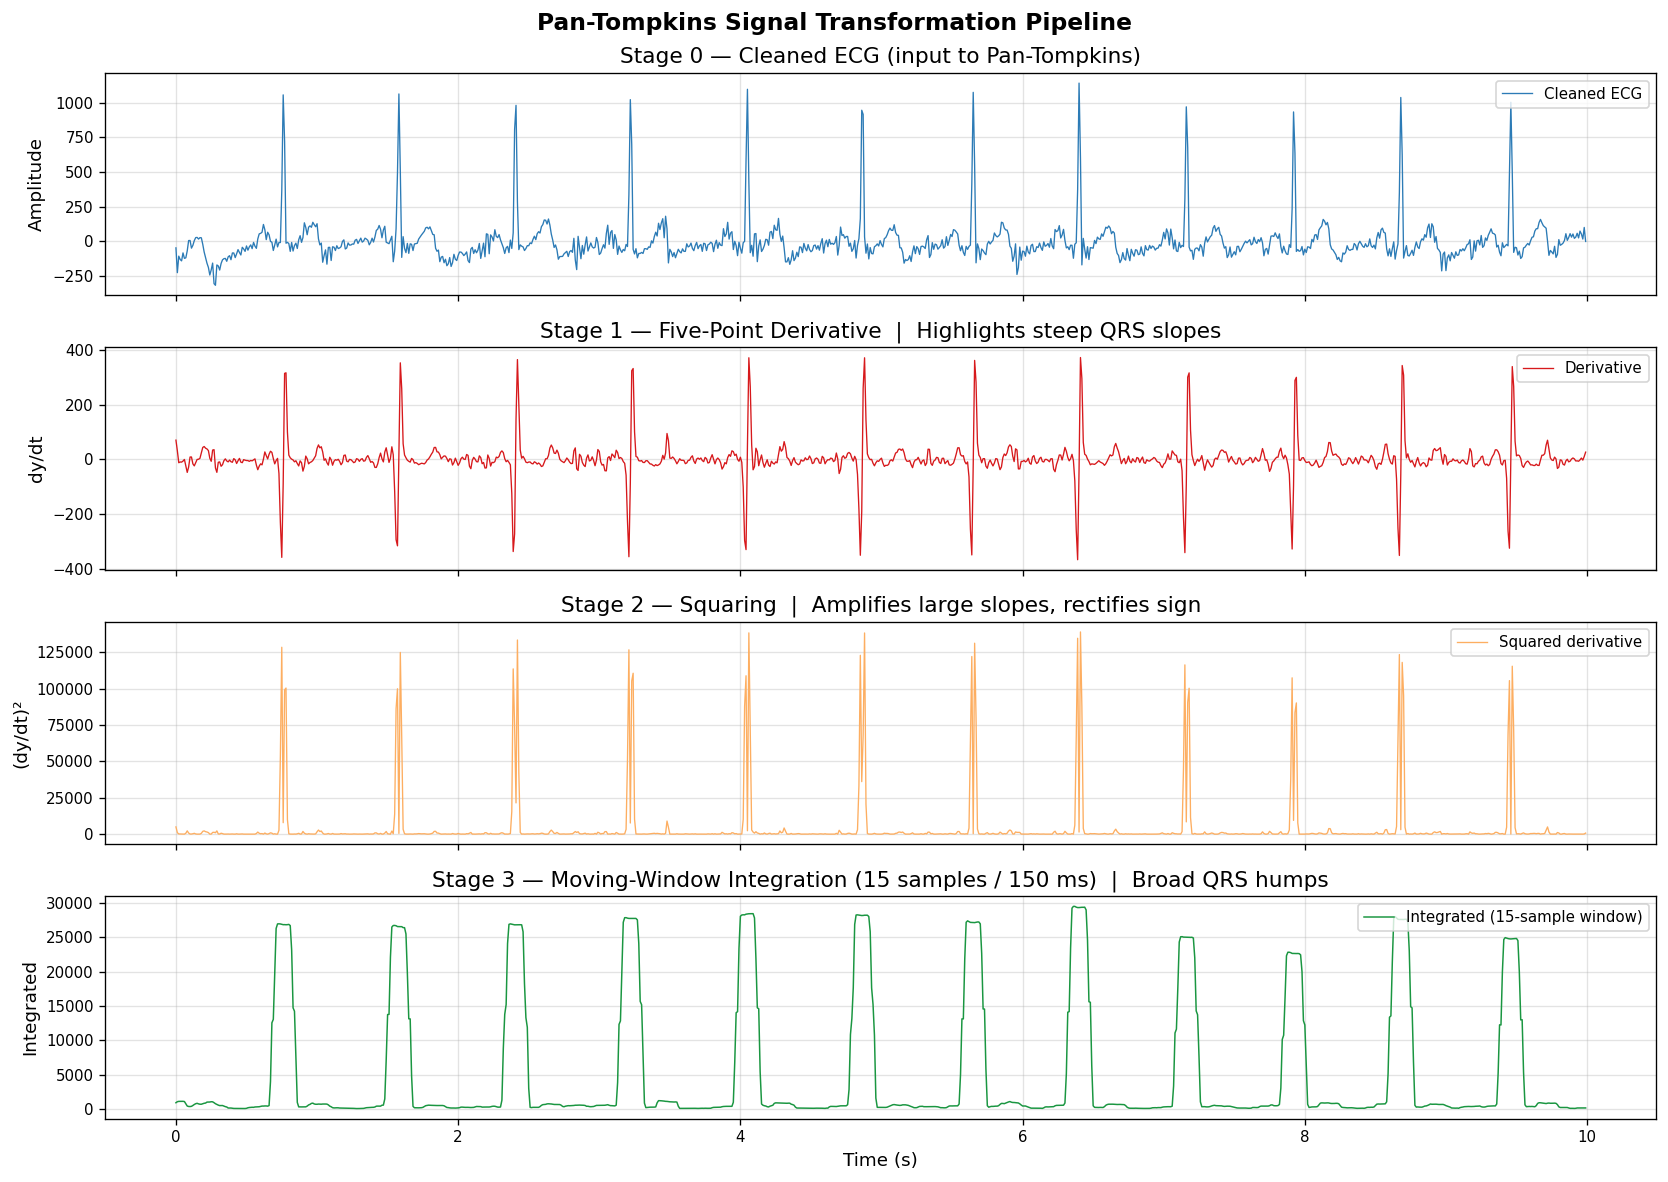

Figure saved: pt_pipeline_stages.pdf


In [106]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 18 — Pan-Tompkins Stage-by-Stage Visualization
# Shows the signal at each transformation step, making the algorithm traceable.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Pan-Tompkins Signal Transformation Pipeline', fontsize=14, fontweight='bold', y=0.98)

axes[0].plot(time_axis, ecg_clean, color='#2c7bb6', linewidth=0.8, label='Cleaned ECG')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Stage 0 — Cleaned ECG (input to Pan-Tompkins)')
axes[0].legend(loc='upper right')
axes[0].grid(True)

axes[1].plot(time_axis, ecg_diff, color='#d7191c', linewidth=0.8, label='Derivative')
axes[1].set_ylabel('dy/dt')
axes[1].set_title('Stage 1 — Five-Point Derivative  |  Highlights steep QRS slopes')
axes[1].legend(loc='upper right')
axes[1].grid(True)

axes[2].plot(time_axis, ecg_sq, color='#fdae61', linewidth=0.8, label='Squared derivative')
axes[2].set_ylabel('(dy/dt)²')
axes[2].set_title('Stage 2 — Squaring  |  Amplifies large slopes, rectifies sign')
axes[2].legend(loc='upper right')
axes[2].grid(True)

axes[3].plot(time_axis, ecg_integrated, color='#1a9641', linewidth=0.9, label=f'Integrated ({W_int}-sample window)')
axes[3].set_ylabel('Integrated')
axes[3].set_xlabel('Time (s)')
axes[3].set_title(f'Stage 3 — Moving-Window Integration ({W_int} samples / {W_int/FS*1000:.0f} ms)  |  Broad QRS humps')
axes[3].legend(loc='upper right')
axes[3].grid(True)

plt.tight_layout()
plt.savefig('pt_pipeline_stages.pdf', bbox_inches='tight')
plt.show()
print("Figure saved: pt_pipeline_stages.pdf")


## Cell 19 — Adaptive Thresholding & R-Peak Detection

### Stage 1d — Adaptive Thresholding

**Theory:**  
Pan & Tompkins use two adaptive thresholds that update after each detected beat:
- **Signal peak estimate ($SPKI$):** tracks the running average of peaks in the integrated signal
- **Noise peak estimate ($NPKI$):** tracks the running average of non-peak (noise) regions
- **Threshold $T_1$:** $NPKI + 0.25 \\times (SPKI - NPKI)$

This approach makes the detector robust to gain drift and signal-level changes over time.

**Simplified implementation here:**  
We use a single global threshold at a fraction of the integrated signal's maximum,
combined with scipy's `find_peaks` which enforces a minimum inter-peak distance (refractory period).

**Refractory period:**  
Normal sinus rhythm has a maximum heart rate of ~220 BPM → minimum RR interval ≈ 273 ms.  
We enforce a minimum inter-peak distance of **200 ms** (conservative) to prevent double-counting.

**Threshold level:**  
Set to 40% of the integrated signal's peak value.  
Rationale: QRS complexes typically produce integrated values > 40% of the global maximum.
This suppresses P waves and T waves whose integrated values are typically < 20% of the maximum.


In [107]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 19 — Adaptive Thresholding & R-Peak Detection
# ─────────────────────────────────────────────────────────────────────────────

# ── Threshold parameters ──────────────────────────────────────────────────────
# THRESHOLD_FRACTION : fraction of the maximum integrated value used as threshold.
#   Typical values: 0.30 (sensitive, more false positives) to 0.50 (specific).
#   We use 0.40 as a physiologically conservative starting point.
THRESHOLD_FRACTION  = 0.40

# MIN_RR_DISTANCE_S : minimum allowed distance between two R peaks (seconds).
#   Based on: maximum physiological heart rate ≈ 220 BPM → min RR ≈ 273 ms.
#   We use 200 ms (0.2 s) to allow slight margin.
MIN_RR_DISTANCE_S   = 0.200
min_distance_samps  = int(MIN_RR_DISTANCE_S * FS)

# Compute threshold
threshold = THRESHOLD_FRACTION * ecg_integrated.max()

# ── find_peaks: local maximum detection with constraints ─────────────────────
# Parameters:
#   height   = threshold  → only peaks above this value are candidates
#   distance = min_distance_samps → enforces refractory period
#   prominence = 0.3 * threshold → peak must 'stand out' from its neighbours
#     (helps reject broad, flat plateaus that might be misdetected as peaks)
#
# NOTE: find_peaks operates on the integrated signal, not the raw ECG.
# The integrated signal produces a single smooth hump per QRS complex,
# making peak detection robust compared to operating directly on the ECG.

r_peaks_int, properties = find_peaks(
    ecg_integrated,
    height     = threshold,
    distance   = min_distance_samps,
    prominence = 0.3 * threshold,
)

# ── Refine R-peak positions onto the original ECG ────────────────────────────
# The integrated signal peak is slightly time-delayed relative to the true
# R peak (due to the moving average window).  We refine by searching for the
# local maximum in the original ecg_clean within a ±(W_int//2) window around
# each detected index.

half_W = W_int // 2 + 5   # refinement search radius (samples)
r_peaks = []
for idx in r_peaks_int:
    lo = max(0, idx - half_W)
    hi = min(N - 1, idx + half_W)
    local_max_idx = lo + np.argmax(np.abs(ecg_clean[lo:hi+1]))
    # Use argmax of absolute value to handle inverted ECG leads
    r_peaks.append(local_max_idx)

r_peaks = np.array(sorted(set(r_peaks)))  # remove duplicates, sort

# If the refined peaks accidentally collapsed, fall back to integrated peaks
if len(r_peaks) == 0:
    r_peaks = r_peaks_int.copy()
    print("[WARNING] Refinement produced no peaks; falling back to integrated-signal peaks.")

# ── Ensure consistent polarity: R peak should be positive ────────────────────
# Some sensors/leads produce inverted ECG. Check median polarity.
r_amplitudes = ecg_clean[r_peaks]
if np.median(r_amplitudes) < 0:
    print("[INFO] Inverted ECG detected — flipping signal polarity for delineation.")
    ecg_clean = -ecg_clean
    r_amplitudes = ecg_clean[r_peaks]

print(f"R-peak detection summary:")
print(f"  Integration-level threshold : {threshold:.6f}  ({THRESHOLD_FRACTION*100:.0f}% of peak)")
print(f"  Min. inter-peak distance    : {min_distance_samps} samples ({MIN_RR_DISTANCE_S*1000:.0f} ms)")
print(f"  Candidate peaks (integrated): {len(r_peaks_int)}")
print(f"  R peaks after refinement    : {len(r_peaks)}")
if len(r_peaks) > 0:
    print(f"  R peak indices              : {r_peaks}")
    print(f"  R peak times (s)            : {r_peaks / FS}")
    print(f"  R amplitude range           : [{r_amplitudes.min():.4f}, {r_amplitudes.max():.4f}]")


R-peak detection summary:
  Integration-level threshold : 11801.742422  (40% of peak)
  Min. inter-peak distance    : 20 samples (200 ms)
  Candidate peaks (integrated): 12
  R peaks after refinement    : 12
  R peak indices              : [ 76 158 241 322 405 486 565 640 716 792 868 946]
  R peak times (s)            : [0.76 1.58 2.41 3.22 4.05 4.86 5.65 6.4  7.16 7.92 8.68 9.46]
  R amplitude range           : [934.7462, 1143.2835]


## Cell 20 — R-Peak Detection Visualization


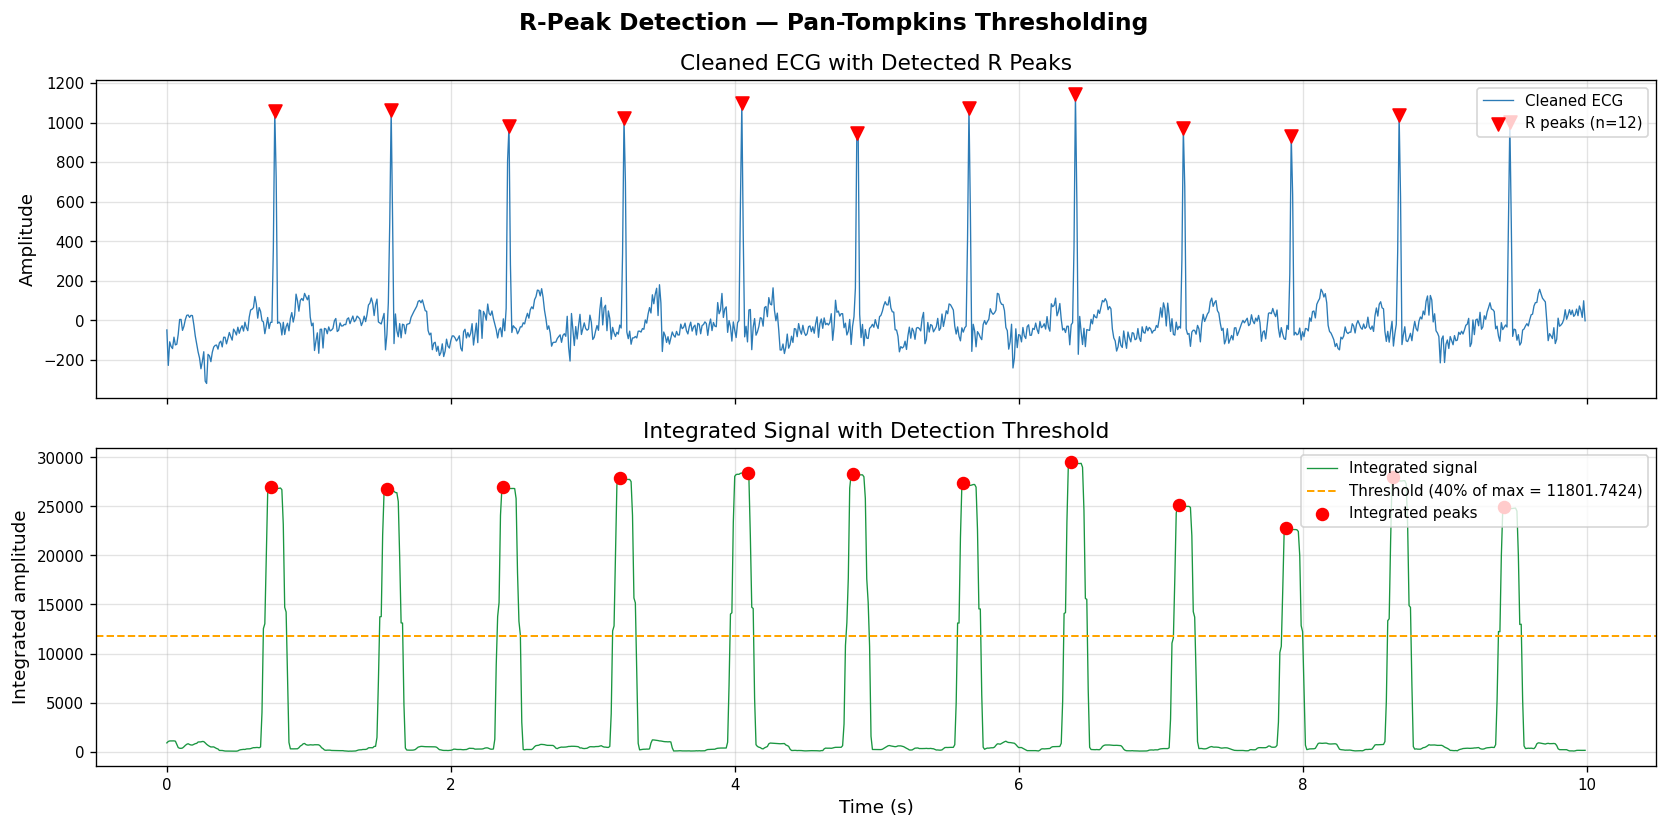

Figure saved: r_peak_detection.pdf


In [108]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 20 — R-Peak Detection Visualization
# Shows: ECG signal with threshold on integrated signal and R peak locations
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('R-Peak Detection — Pan-Tompkins Thresholding', fontsize=14, fontweight='bold')

# Top: ECG with R peaks marked
axes[0].plot(time_axis, ecg_clean, color='#2c7bb6', linewidth=0.8, label='Cleaned ECG', zorder=2)
if len(r_peaks) > 0:
    axes[0].scatter(r_peaks / FS, ecg_clean[r_peaks], color='red', s=60,
                    zorder=5, label=f'R peaks (n={len(r_peaks)})', marker='v')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Cleaned ECG with Detected R Peaks')
axes[0].legend(loc='upper right')
axes[0].grid(True)

# Bottom: integrated signal with threshold line
axes[1].plot(time_axis, ecg_integrated, color='#1a9641', linewidth=0.8, label='Integrated signal', zorder=2)
axes[1].axhline(threshold, color='orange', linewidth=1.2, linestyle='--',
                label=f'Threshold ({THRESHOLD_FRACTION*100:.0f}% of max = {threshold:.4f})')
if len(r_peaks_int) > 0:
    axes[1].scatter(r_peaks_int / FS, ecg_integrated[r_peaks_int], color='red', s=50,
                    zorder=5, label='Integrated peaks', marker='o')
axes[1].set_ylabel('Integrated amplitude')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Integrated Signal with Detection Threshold')
axes[1].legend(loc='upper right')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('r_peak_detection.pdf', bbox_inches='tight')
plt.show()
print("Figure saved: r_peak_detection.pdf")


---
## Step 2 — Q and S Point Detection

### Physiological Background

The QRS complex reflects ventricular depolarisation and consists of three deflections:

| Wave | Physiological origin | Polarity (normal lead II) | Duration |
|------|----------------------|---------------------------|----------|
| Q    | Septal depolarisation (left → right) | Negative | < 40 ms |
| R    | Main ventricular depolarisation | Positive (largest) | — |
| S    | Basal ventricular depolarisation | Negative | < 40 ms |

**Total QRS duration:** 60–110 ms (< 120 ms normal; ≥ 120 ms = bundle branch block)

### Detection Method: Local Minima Search

**Q point:** The local minimum in the signal in a window **before** each R peak.  
**Search window:** [R − 60 ms, R − 5 ms] (physiological QRS onset to R peak)  

**S point:** The local minimum in the signal in a window **after** each R peak.  
**Search window:** [R + 5 ms, R + 60 ms] (R peak to QRS offset)

**Why local minima correspond to Q and S:**  
The Q wave is the first negative deflection before the R peak — it marks the beginning of septal
depolarisation and appears as a trough in the signal.  
The S wave is the negative deflection following the R peak — it marks the completion of ventricular
depolarisation and also appears as a trough.  
Both are found by identifying the minimum value in a physiologically constrained local window.

**Search window rationale:**  
- A 5 ms guard band on each side of R prevents detecting the R peak itself as Q or S.
- The 60 ms outer boundary is set at 0.5 × maximum expected QRS duration (120 ms).
  This prevents searching into the adjacent T or P wave territory.

**Limitation:**  
Q waves are absent in ~30% of normal leads.  
In such cases, the algorithm will detect a local minimum that may be near the QRS onset
rather than a true discrete Q deflection.  
S waves may also be absent in certain lead configurations.


## Cell 21 — Q and S Detection


In [109]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 21 — Q and S Detection via Local Minima Search
# ─────────────────────────────────────────────────────────────────────────────

# ── Search window parameters (in seconds) ────────────────────────────────────
# These are physiologically derived from AHA ECG standards.
#
# QRS onset to R peak: typically 20–60 ms.  We search [5 ms, 60 ms] before R.
# R peak to QRS offset: typically 20–60 ms.  We search [5 ms, 60 ms] after R.

Q_SEARCH_BEFORE_S = 0.005   # 5 ms guard — do not search too close to R
Q_SEARCH_BEFORE_E = 0.060   # 60 ms — QRS onset upper bound
S_SEARCH_AFTER_S  = 0.005   # 5 ms guard
S_SEARCH_AFTER_E  = 0.060   # 60 ms — QRS offset upper bound

# Convert to samples
q_guard  = max(1, int(Q_SEARCH_BEFORE_S * FS))
q_window = max(q_guard + 1, int(Q_SEARCH_BEFORE_E * FS))
s_guard  = max(1, int(S_SEARCH_AFTER_S  * FS))
s_window = max(s_guard + 1, int(S_SEARCH_AFTER_E  * FS))

q_peaks = []
s_peaks = []

for r_idx in r_peaks:

    # ── Q detection ───────────────────────────────────────────────────────────
    # Search region: [r_idx - q_window, r_idx - q_guard]
    # We find the minimum of ecg_clean in this region.
    # If the region is out of bounds (R near start of recording) we skip.

    q_lo = r_idx - q_window
    q_hi = r_idx - q_guard

    if q_lo >= 0 and q_hi > q_lo:
        local_min_offset = np.argmin(ecg_clean[q_lo:q_hi])
        q_peaks.append(q_lo + local_min_offset)
    else:
        q_peaks.append(None)   # Q not detectable for this beat

    # ── S detection ───────────────────────────────────────────────────────────
    # Search region: [r_idx + s_guard, r_idx + s_window]

    s_lo = r_idx + s_guard
    s_hi = r_idx + s_window

    if s_hi <= N - 1 and s_hi > s_lo:
        local_min_offset = np.argmin(ecg_clean[s_lo:s_hi])
        s_peaks.append(s_lo + local_min_offset)
    else:
        s_peaks.append(None)   # S not detectable for this beat

print(f"Q/S detection summary:")
print(f"  Q search window : [{Q_SEARCH_BEFORE_S*1000:.0f}, {Q_SEARCH_BEFORE_E*1000:.0f}] ms before R")
print(f"  S search window : [{S_SEARCH_AFTER_S*1000:.0f}, {S_SEARCH_AFTER_E*1000:.0f}] ms after R")
print(f"  Beats analysed  : {len(r_peaks)}")
q_valid = [q for q in q_peaks if q is not None]
s_valid = [s for s in s_peaks if s is not None]
print(f"  Q peaks detected: {len(q_valid)} / {len(r_peaks)}")
print(f"  S peaks detected: {len(s_valid)} / {len(r_peaks)}")


Q/S detection summary:
  Q search window : [5, 60] ms before R
  S search window : [5, 60] ms after R
  Beats analysed  : 12
  Q peaks detected: 12 / 12
  S peaks detected: 12 / 12


## Cell 22 — QRS Delineation Visualization


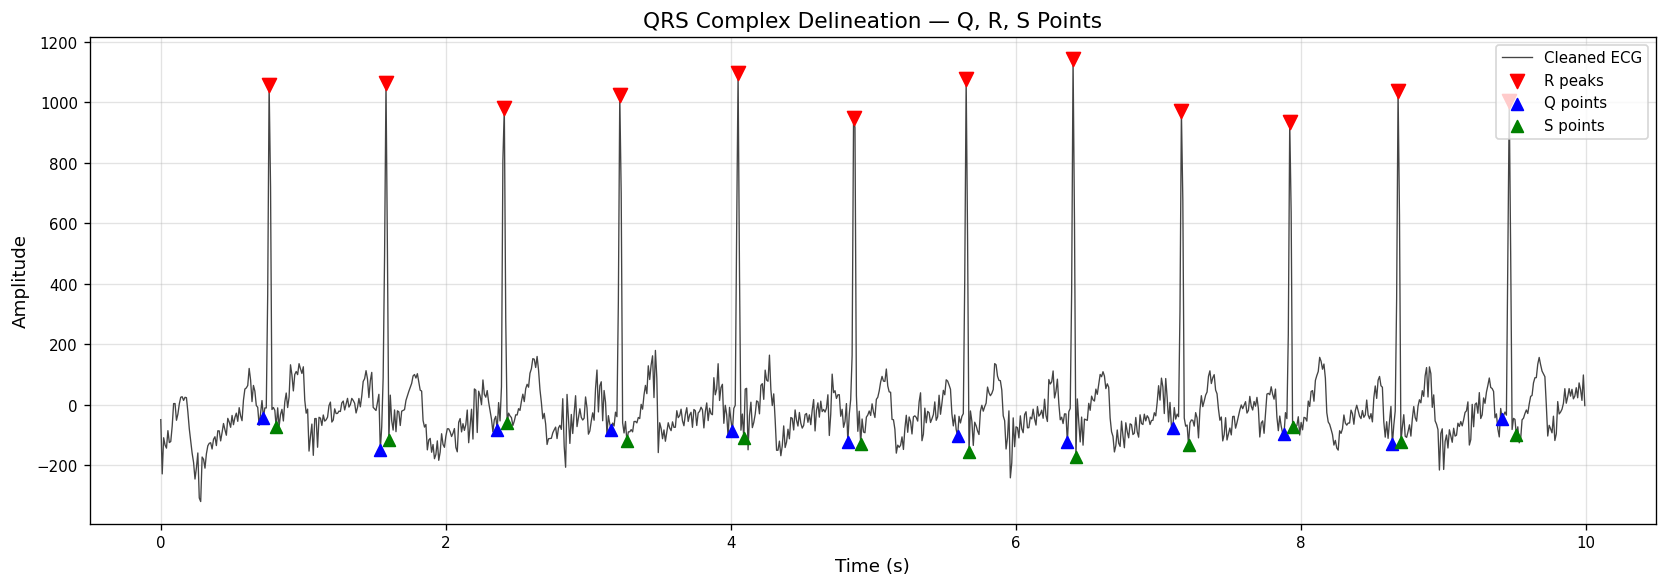

Figure saved: qrs_delineation.pdf


In [110]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 22 — QRS Delineation Plot
# Shows cleaned ECG with Q, R, S markers for every detected beat.
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_axis, ecg_clean, color='#444444', linewidth=0.8, label='Cleaned ECG', zorder=2)

# R peaks
if len(r_peaks) > 0:
    ax.scatter(r_peaks / FS, ecg_clean[r_peaks],
               color='red', s=70, zorder=5, label='R peaks', marker='v')

# Q peaks
q_arr = np.array([q for q in q_peaks if q is not None])
if len(q_arr) > 0:
    ax.scatter(q_arr / FS, ecg_clean[q_arr],
               color='blue', s=50, zorder=5, label='Q points', marker='^')

# S peaks
s_arr = np.array([s for s in s_peaks if s is not None])
if len(s_arr) > 0:
    ax.scatter(s_arr / FS, ecg_clean[s_arr],
               color='green', s=50, zorder=5, label='S points', marker='^')

ax.set_title('QRS Complex Delineation — Q, R, S Points')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend(loc='upper right')
ax.grid(True)
plt.tight_layout()
plt.savefig('qrs_delineation.pdf', bbox_inches='tight')
plt.show()
print("Figure saved: qrs_delineation.pdf")


---
## Step 3 — P and T Peak Detection

### Physiological Background

| Wave | Physiological origin | Normal timing (relative to R) | Typical amplitude |
|------|----------------------|--------------------------------|-------------------|
| P    | Atrial depolarisation (SA node → AV node) | −200 to −80 ms (before QRS) | 0.05–0.25 mV |
| T    | Ventricular repolarisation | +150 to +400 ms (after QRS) | 0.1–0.5 mV |

### P-Wave Detection

**Search window:** [preceding R peak + 200 ms, current R − 80 ms]

**Rationale:**
- The P wave precedes the QRS by the PR interval (120–200 ms in normal sinus rhythm).
- We search in the region between the end of the preceding T wave and the onset of the current QRS.
- The lower bound is set 200 ms after the preceding R peak (to skip the T wave).
- The upper bound is 80 ms before the current R peak (to stay outside the QRS complex).

**Why P occurs before QRS:**  
The sinoatrial node fires, causing atrial depolarisation (P wave).  
After the AV node delay (~120 ms of the PR interval), the signal reaches the ventricles → QRS.

### T-Wave Detection

**Search window:** [current S peak + 20 ms, current S peak + 400 ms] (capped by next R − 100 ms)

**Rationale:**
- The QT interval (R to end of T) is 350–440 ms at normal heart rates.
- We search from the QRS offset (S point + 20 ms) up to 400 ms post-R, capped to avoid encroaching on the next beat.
- The T wave is the dominant positive deflection in this window under normal conditions.

**Why T occurs after QRS:**  
The T wave reflects ventricular repolarisation (Phases 2 and 3 of the action potential).
Repolarisation is intrinsically slower than depolarisation because it depends on potassium channel kinetics.

**Limitation:**  
At high heart rates (> 120 BPM), the T wave of one beat may overlap with the P wave of the next.
The search window automatically shrinks in such cases (capped by next R peak), but T-wave delineation
becomes unreliable above ~160 BPM.


## Cell 23 — P and T Peak Detection


In [111]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 23 — P and T Peak Detection
# ─────────────────────────────────────────────────────────────────────────────

# ── Search window parameters ─────────────────────────────────────────────────
# All in seconds, physiologically grounded in AHA ECG standards.

P_BEFORE_R_END   = 0.080   # 80 ms before R = latest P could end (QRS onset guard)
P_AFTER_PREV_R   = 0.200   # 200 ms after previous R = earliest P could start (past T wave)

T_AFTER_S_START  = 0.020   # 20 ms after S = start of T search (past QRS offset)
T_AFTER_S_MAX    = 0.400   # 400 ms after S = absolute latest T peak
T_BEFORE_NEXT_R  = 0.100   # 100 ms before next R = safety margin

p_peaks = []
t_peaks = []

for i, r_idx in enumerate(r_peaks):

    # ────────────────────────────────────────────────────────────────────────
    # P-wave detection
    # ────────────────────────────────────────────────────────────────────────
    #
    # Lower bound of search window:
    #   If a previous R peak exists, start search P_AFTER_PREV_R seconds after it.
    #   Otherwise, start at the beginning of the signal.
    #
    # Upper bound of search window:
    #   P_BEFORE_R_END seconds before the current R peak.

    if i > 0:
        p_lo = int(r_peaks[i-1] + P_AFTER_PREV_R * FS)
    else:
        p_lo = max(0, int(r_idx - 0.300 * FS))  # First beat: search 300 ms before R

    p_hi = int(r_idx - P_BEFORE_R_END * FS)

    if p_lo < p_hi and p_lo >= 0 and p_hi <= N:
        # Find local maximum in the P search window
        local_max_offset = np.argmax(ecg_clean[p_lo:p_hi])
        p_peaks.append(p_lo + local_max_offset)
    else:
        p_peaks.append(None)

    # ────────────────────────────────────────────────────────────────────────
    # T-wave detection
    # ────────────────────────────────────────────────────────────────────────
    #
    # Use the detected S point as the start reference if available;
    # otherwise fall back to R + 40 ms.
    #
    # Upper bound is capped at (next R peak − T_BEFORE_NEXT_R) to prevent
    # the T wave search from leaking into the next beat.

    s_idx = s_peaks[i] if (i < len(s_peaks) and s_peaks[i] is not None) else None
    t_ref = s_idx if s_idx is not None else int(r_idx + 0.040 * FS)

    t_lo = int(t_ref + T_AFTER_S_START * FS)
    t_hi = int(t_ref + T_AFTER_S_MAX   * FS)

    # Cap by the next R peak minus safety margin
    if i + 1 < len(r_peaks):
        next_r_cap = int(r_peaks[i+1] - T_BEFORE_NEXT_R * FS)
        t_hi = min(t_hi, next_r_cap)

    t_hi = min(t_hi, N - 1)

    if t_lo < t_hi and t_lo >= 0:
        local_max_offset = np.argmax(ecg_clean[t_lo:t_hi])
        t_peaks.append(t_lo + local_max_offset)
    else:
        t_peaks.append(None)

p_valid = [p for p in p_peaks if p is not None]
t_valid = [t for t in t_peaks if t is not None]

print(f"P/T detection summary:")
print(f"  P search window : {P_AFTER_PREV_R*1000:.0f} ms after prev R  →  {P_BEFORE_R_END*1000:.0f} ms before R")
print(f"  T search window : {T_AFTER_S_START*1000:.0f} ms after S  →  {T_AFTER_S_MAX*1000:.0f} ms (capped by next R)")
print(f"  P peaks detected: {len(p_valid)} / {len(r_peaks)}")
print(f"  T peaks detected: {len(t_valid)} / {len(r_peaks)}")


P/T detection summary:
  P search window : 200 ms after prev R  →  80 ms before R
  T search window : 20 ms after S  →  400 ms (capped by next R)
  P peaks detected: 12 / 12
  T peaks detected: 12 / 12


## Cell 24 — Complete PQRST Delineation Visualization


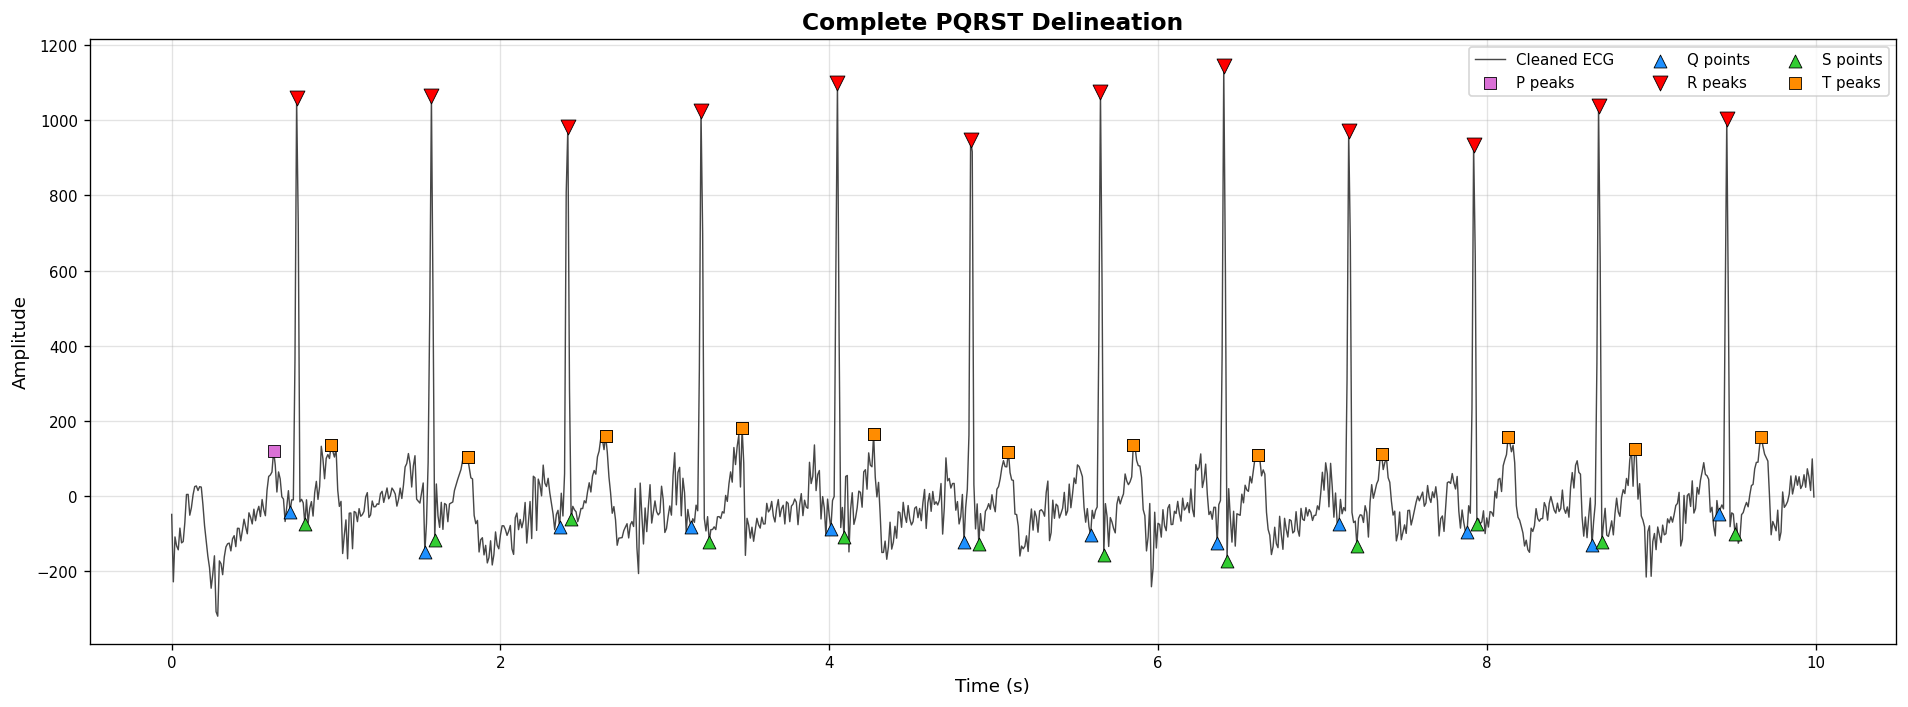

Figure saved: pqrst_delineation.pdf


In [112]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 24 — Complete PQRST Delineation Figure
# Publication-quality plot showing all five ECG fiducial points simultaneously.
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(time_axis, ecg_clean, color='#333333', linewidth=0.85,
        label='Cleaned ECG', zorder=2, alpha=0.9)

# ── Colour and marker scheme ─────────────────────────────────────────────────
# Each wave has a distinct colour and marker to allow visual disambiguation.
MARKERS = {
    'P': ('orchid',  's', 60, 'P peaks'),
    'Q': ('dodgerblue', '^', 60, 'Q points'),
    'R': ('red',     'v', 80, 'R peaks'),
    'S': ('limegreen', '^', 60, 'S points'),
    'T': ('darkorange', 's', 60, 'T peaks'),
}

def scatter_peaks(ax, indices_or_list, ecg, ta, key):
    idxs = np.array([x for x in indices_or_list if x is not None and 0 <= x < len(ecg)])
    if len(idxs) == 0:
        return
    c, m, s, lbl = MARKERS[key]
    ax.scatter(idxs / FS, ecg[idxs], color=c, s=s, zorder=5, label=lbl,
               marker=m, edgecolors='black', linewidths=0.5)

scatter_peaks(ax, p_peaks, ecg_clean, time_axis, 'P')
scatter_peaks(ax, q_peaks, ecg_clean, time_axis, 'Q')
scatter_peaks(ax, r_peaks, ecg_clean, time_axis, 'R')
scatter_peaks(ax, s_peaks, ecg_clean, time_axis, 'S')
scatter_peaks(ax, t_peaks, ecg_clean, time_axis, 'T')

ax.set_title('Complete PQRST Delineation', fontsize=14, fontweight='bold')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend(loc='upper right', ncol=3)
ax.grid(True)
plt.tight_layout()
plt.savefig('pqrst_delineation.pdf', bbox_inches='tight')
plt.show()
print("Figure saved: pqrst_delineation.pdf")


## Cell 25 — Zoomed Single-Beat PQRST View


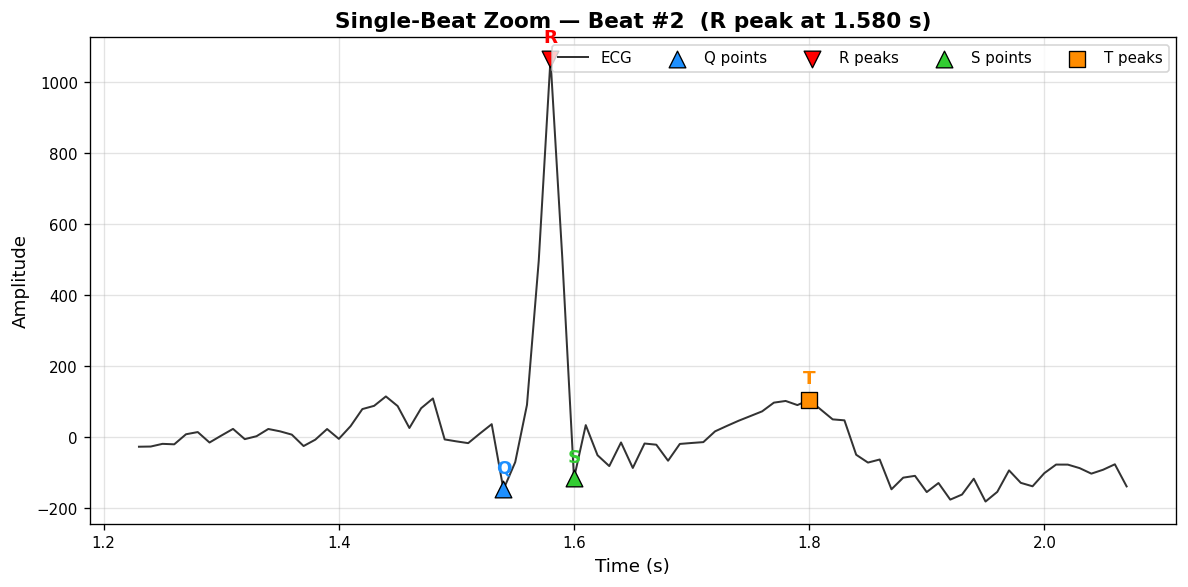

Figure saved: single_beat_zoom.pdf


In [113]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 25 — Zoomed Single-Beat PQRST View
# Renders the 2nd or middle beat in high resolution to clearly show the
# anatomy of one complete cardiac cycle.
# ─────────────────────────────────────────────────────────────────────────────

if len(r_peaks) >= 2:
    beat_idx = min(1, len(r_peaks) - 1)   # pick 2nd beat (index 1)
    r_center = r_peaks[beat_idx]

    # Show 350 ms before and 500 ms after R peak
    zoom_lo = max(0, r_center - int(0.35 * FS))
    zoom_hi = min(N - 1, r_center + int(0.50 * FS))

    t_zoom  = time_axis[zoom_lo:zoom_hi]
    ecg_zoom = ecg_clean[zoom_lo:zoom_hi]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(t_zoom, ecg_zoom, color='#333333', linewidth=1.2, label='ECG', zorder=2)

    def scatter_if_valid(ax, idx, ecg, ta, key):
        if idx is not None and zoom_lo <= idx < zoom_hi:
            c, m, s, lbl = MARKERS[key]
            ax.scatter(ta[idx], ecg[idx], color=c, s=100, zorder=5,
                       marker=m, edgecolors='black', linewidths=0.8, label=lbl)
            ax.annotate(key, (ta[idx], ecg[idx]),
                        textcoords='offset points', xytext=(0, 10),
                        ha='center', fontsize=11, fontweight='bold', color=c)

    scatter_if_valid(ax, p_peaks[beat_idx] if beat_idx < len(p_peaks) else None, ecg_clean, time_axis, 'P')
    scatter_if_valid(ax, q_peaks[beat_idx] if beat_idx < len(q_peaks) else None, ecg_clean, time_axis, 'Q')
    scatter_if_valid(ax, r_peaks[beat_idx],                                       ecg_clean, time_axis, 'R')
    scatter_if_valid(ax, s_peaks[beat_idx] if beat_idx < len(s_peaks) else None, ecg_clean, time_axis, 'S')
    scatter_if_valid(ax, t_peaks[beat_idx] if beat_idx < len(t_peaks) else None, ecg_clean, time_axis, 'T')

    ax.set_title(f'Single-Beat Zoom — Beat #{beat_idx+1}  (R peak at {r_center/FS:.3f} s)', fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', ncol=5)
    ax.grid(True)
    plt.tight_layout()
    plt.savefig('single_beat_zoom.pdf', bbox_inches='tight')
    plt.show()
    print("Figure saved: single_beat_zoom.pdf")
else:
    print("[INFO] Fewer than 2 R peaks detected — single-beat zoom skipped.")


---
## Step 4 — RR Intervals and Heart Rate Variability (HRV)

### Definitions

| Metric | Definition | Formula |
|--------|-----------|--------|
| RR interval | Time between consecutive R peaks | $RR_i = (R_{i+1} - R_i) / F_s$ |
| Heart rate | Beats per minute from each interval | $HR_i = 60 / RR_i$ |
| Mean RR | Average RR interval | $\\overline{RR}$ |
| SDNN | Std dev of all NN intervals | $\\sigma_{RR}$ |
| RMSSD | Root mean square of successive differences | $\\sqrt{\\frac{1}{N-1}\\sum(RR_{i+1}-RR_i)^2}$ |
| pNN50 | % of successive differences > 50 ms | $100 \\times \\frac{|\\{|\\Delta RR| > 50\\text{ ms}\\}|}{N-1}$ |

### Clinical Significance

**SDNN** reflects overall autonomic variability (sympathetic + parasympathetic).  
Normal range (5-minute recording): 50–150 ms. Low SDNN (< 50 ms) is associated with increased cardiac mortality.

**RMSSD** reflects parasympathetic (vagal) activity.  
Normal range: 20–50 ms. High RMSSD indicates strong vagal tone (physically fit individuals).

**pNN50** is a derivative of RMSSD, more robust to outliers.  
Normal range: 5–40% in healthy adults.

**Note:** Standard HRV analysis requires ≥ 5 minutes of recording for frequency-domain metrics.
The time-domain metrics above are meaningful even on short 10-second recordings as beat-by-beat indicators.


## Cell 26 — RR Interval & HRV Computation


In [114]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 26 — RR Intervals, Heart Rate, and HRV Statistics
# ─────────────────────────────────────────────────────────────────────────────

if len(r_peaks) < 2:
    print("[WARNING] Fewer than 2 R peaks detected — cannot compute RR intervals.")
    rr_intervals = np.array([])
    hr_bpm = np.array([])
else:
    # ── RR intervals ─────────────────────────────────────────────────────────
    # np.diff(r_peaks) gives inter-peak distances in samples.
    # Dividing by FS converts to seconds.
    # Normal range: 0.27 s (220 BPM) to 2.00 s (30 BPM)
    rr_intervals = np.diff(r_peaks) / FS   # seconds

    # ── Instantaneous heart rate ──────────────────────────────────────────────
    # HR_i = 60 / RR_i   (BPM)
    # Guard against division by zero (rr = 0 is physiologically impossible but
    # can occur if two peaks were accidentally detected at the same sample).
    hr_bpm = np.where(rr_intervals > 0, 60.0 / rr_intervals, np.nan)

    # ── HRV time-domain statistics ────────────────────────────────────────────
    rr_ms       = rr_intervals * 1000   # Convert to ms for HRV metrics
    rr_diff     = np.diff(rr_ms)        # Successive differences (ms)

    mean_rr     = np.nanmean(rr_ms)
    std_rr      = np.nanstd(rr_ms, ddof=1) if len(rr_ms) > 1 else np.nan  # SDNN
    min_rr      = np.nanmin(rr_ms)
    max_rr      = np.nanmax(rr_ms)
    mean_hr     = np.nanmean(hr_bpm)
    min_hr      = np.nanmin(hr_bpm)
    max_hr      = np.nanmax(hr_bpm)

    # RMSSD: root mean square of successive RR differences
    rmssd = np.sqrt(np.nanmean(rr_diff**2)) if len(rr_diff) > 0 else np.nan

    # pNN50: fraction of successive differences > 50 ms
    if len(rr_diff) > 0:
        pnn50 = 100.0 * np.sum(np.abs(rr_diff) > 50.0) / len(rr_diff)
    else:
        pnn50 = np.nan

    # ── Print report ──────────────────────────────────────────────────────────
    print("═" * 60)
    print("  HEART RATE & HRV SUMMARY")
    print("═" * 60)
    print(f"  Total beats detected   : {len(r_peaks)}")
    print(f"  Recording duration     : {N/FS:.2f} s")
    print(f"  Number of RR intervals : {len(rr_intervals)}")
    print()
    print("  ▸ Heart Rate")
    print(f"    Mean HR            : {mean_hr:.1f} BPM")
    print(f"    Min  HR            : {min_hr:.1f} BPM")
    print(f"    Max  HR            : {max_hr:.1f} BPM")
    print()
    print("  ▸ RR Intervals")
    print(f"    Mean RR            : {mean_rr:.1f} ms")
    print(f"    Min  RR            : {min_rr:.1f} ms")
    print(f"    Max  RR            : {max_rr:.1f} ms")
    print(f"    RR range           : {max_rr - min_rr:.1f} ms")
    print()
    print("  ▸ HRV Time-Domain Metrics")
    print(f"    SDNN               : {std_rr:.2f} ms  (total RR std dev)")
    print(f"    RMSSD              : {rmssd:.2f} ms  (parasympathetic index)")
    print(f"    pNN50              : {pnn50:.1f} %   (% successive diff > 50 ms)")
    print("═" * 60)


════════════════════════════════════════════════════════════
  HEART RATE & HRV SUMMARY
════════════════════════════════════════════════════════════
  Total beats detected   : 12
  Recording duration     : 10.00 s
  Number of RR intervals : 11

  ▸ Heart Rate
    Mean HR            : 76.0 BPM
    Min  HR            : 72.3 BPM
    Max  HR            : 80.0 BPM

  ▸ RR Intervals
    Mean RR            : 790.9 ms
    Min  RR            : 750.0 ms
    Max  RR            : 830.0 ms
    RR range           : 80.0 ms

  ▸ HRV Time-Domain Metrics
    SDNN               : 30.48 ms  (total RR std dev)
    RMSSD              : 19.49 ms  (parasympathetic index)
    pNN50              : 0.0 %   (% successive diff > 50 ms)
════════════════════════════════════════════════════════════


## Cell 27 — RR Interval and Heart Rate Plots


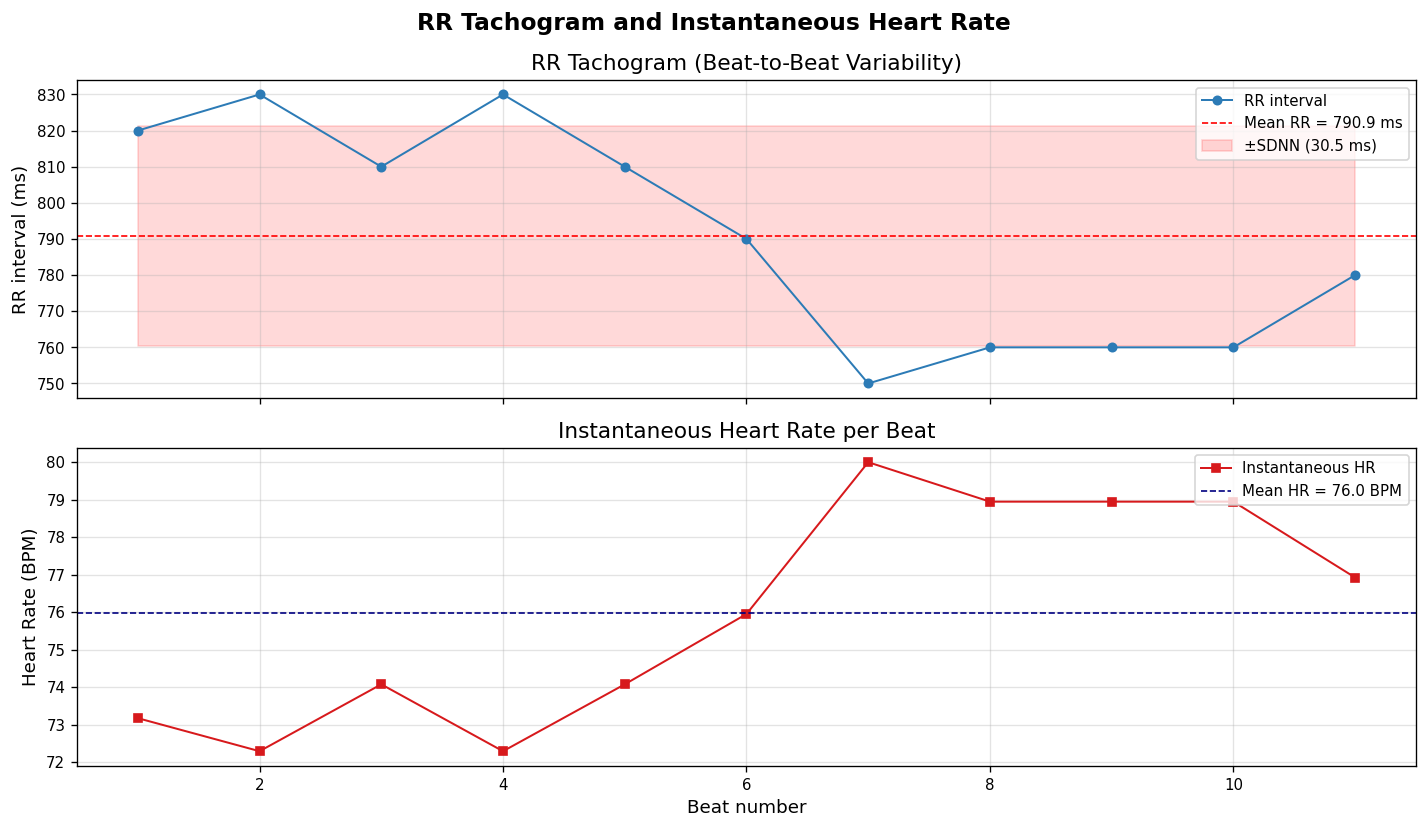

Figure saved: rr_tachogram.pdf


In [115]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 27 — RR Interval Tachogram and Instantaneous Heart Rate
# A tachogram plots successive RR intervals against beat number, revealing
# beat-to-beat variability — the raw signal for HRV analysis.
# ─────────────────────────────────────────────────────────────────────────────

if len(rr_intervals) >= 2:
    beat_numbers = np.arange(1, len(rr_intervals) + 1)

    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle('RR Tachogram and Instantaneous Heart Rate', fontsize=14, fontweight='bold')

    # RR tachogram
    axes[0].plot(beat_numbers, rr_ms, 'o-', color='#2c7bb6', linewidth=1.2,
                 markersize=5, label='RR interval')
    axes[0].axhline(mean_rr, color='red', linewidth=1.0, linestyle='--',
                    label=f'Mean RR = {mean_rr:.1f} ms')
    axes[0].fill_between(beat_numbers,
                         mean_rr - std_rr, mean_rr + std_rr,
                         alpha=0.15, color='red', label=f'±SDNN ({std_rr:.1f} ms)')
    axes[0].set_ylabel('RR interval (ms)')
    axes[0].set_title('RR Tachogram (Beat-to-Beat Variability)')
    axes[0].legend(loc='upper right')
    axes[0].grid(True)

    # Instantaneous HR
    axes[1].plot(beat_numbers, hr_bpm, 's-', color='#d7191c', linewidth=1.2,
                 markersize=5, label='Instantaneous HR')
    axes[1].axhline(mean_hr, color='navy', linewidth=1.0, linestyle='--',
                    label=f'Mean HR = {mean_hr:.1f} BPM')
    axes[1].set_ylabel('Heart Rate (BPM)')
    axes[1].set_xlabel('Beat number')
    axes[1].set_title('Instantaneous Heart Rate per Beat')
    axes[1].legend(loc='upper right')
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig('rr_tachogram.pdf', bbox_inches='tight')
    plt.show()
    print("Figure saved: rr_tachogram.pdf")
else:
    print("[INFO] Insufficient RR intervals for tachogram plot.")


---
## Step 5 — Physiological Validation

This section performs rule-based sanity checks on all detected peaks and
computed metrics.  Warnings are issued when values fall outside the physiologically
expected range.  These checks are **not diagnostic** — they indicate potential
signal quality issues or algorithm failures that should be reviewed.

**Normal sinus rhythm reference values (AHA/ACC ECG standards):**

| Parameter | Normal range | Warning threshold |
|-----------|-------------|-------------------|
| Heart rate | 60–100 BPM | < 40 or > 180 BPM |
| RR interval | 600–1000 ms | < 273 ms or > 2000 ms |
| PR interval | 120–200 ms | < 80 ms or > 300 ms |
| QRS duration | 60–120 ms | < 40 ms or > 200 ms |
| QT interval | 350–440 ms | < 200 ms or > 600 ms |


## Cell 28 — Physiological Validation


In [116]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 28 — Physiological Validation & Diagnostic Warnings
# ─────────────────────────────────────────────────────────────────────────────

print("═" * 65)
print("  PHYSIOLOGICAL VALIDATION — ECG DELINEATION")
print("═" * 65)

warnings_list = []
passed_list   = []

def check(condition, passed_msg, warn_msg):
    if condition:
        passed_list.append(passed_msg)
        print(f"  ✓  {passed_msg}")
    else:
        warnings_list.append(warn_msg)
        print(f"  ⚠  {warn_msg}")

# ── Beat count ────────────────────────────────────────────────────────────────
expected_beats_lo = max(1, int(0.4 * N / FS))   # 40 BPM minimum
expected_beats_hi = int(3.0 * N / FS)            # 180 BPM maximum
check(expected_beats_lo <= len(r_peaks) <= expected_beats_hi,
      f"Beat count ({len(r_peaks)}) is within expected range [{expected_beats_lo}, {expected_beats_hi}]",
      f"Beat count ({len(r_peaks)}) outside expected range [{expected_beats_lo}, {expected_beats_hi}] — check signal quality")

# ── Heart rate range ─────────────────────────────────────────────────────────
if len(hr_bpm) > 0 and not np.all(np.isnan(hr_bpm)):
    hr_mean_val = float(np.nanmean(hr_bpm))
    check(40 <= hr_mean_val <= 180,
          f"Mean HR ({hr_mean_val:.1f} BPM) within physiological range [40, 180]",
          f"Mean HR ({hr_mean_val:.1f} BPM) outside range — bradycardia (< 40) or tachycardia (> 180)")
    check(hr_mean_val < 180,
          f"No extreme tachycardia (HR < 180 BPM)",
          f"Extreme tachycardia (HR = {hr_mean_val:.1f} BPM) — verify R-peak detection accuracy")
    check(hr_mean_val > 40,
          f"No extreme bradycardia (HR > 40 BPM)",
          f"Extreme bradycardia (HR = {hr_mean_val:.1f} BPM) — verify R-peak detection accuracy")

# ── RR intervals ─────────────────────────────────────────────────────────────
if len(rr_intervals) > 0:
    rr_min_ms_val = float(np.nanmin(rr_ms))
    rr_max_ms_val = float(np.nanmax(rr_ms))
    check(rr_min_ms_val >= 270,
          f"Min RR interval ({rr_min_ms_val:.1f} ms) ≥ 270 ms (≤ 220 BPM)",
          f"Min RR interval ({rr_min_ms_val:.1f} ms) < 270 ms — possible double-detection or extreme tachycardia")
    check(rr_max_ms_val <= 2000,
          f"Max RR interval ({rr_max_ms_val:.1f} ms) ≤ 2000 ms (≥ 30 BPM)",
          f"Max RR interval ({rr_max_ms_val:.1f} ms) > 2000 ms — possible missed beat or extreme bradycardia")

# ── PR interval check ─────────────────────────────────────────────────────────
pr_intervals_ms = []
for i, r_idx in enumerate(r_peaks):
    if i < len(p_peaks) and p_peaks[i] is not None:
        pr_ms = (r_idx - p_peaks[i]) / FS * 1000
        if 0 < pr_ms < 500:   # Sanity guard
            pr_intervals_ms.append(pr_ms)

if len(pr_intervals_ms) > 0:
    mean_pr = float(np.mean(pr_intervals_ms))
    check(80 <= mean_pr <= 300,
          f"Mean PR interval ({mean_pr:.1f} ms) within normal range [80, 300 ms]",
          f"Mean PR interval ({mean_pr:.1f} ms) outside normal range — possible AV block or ectopic P")

# ── QRS duration check ────────────────────────────────────────────────────────
qrs_durations_ms = []
for i in range(len(r_peaks)):
    q_i = q_peaks[i] if i < len(q_peaks) else None
    s_i = s_peaks[i] if i < len(s_peaks) else None
    if q_i is not None and s_i is not None and s_i > q_i:
        qrs_durations_ms.append((s_i - q_i) / FS * 1000)

if len(qrs_durations_ms) > 0:
    mean_qrs = float(np.mean(qrs_durations_ms))
    check(40 <= mean_qrs <= 200,
          f"Mean QRS duration ({mean_qrs:.1f} ms) within range [40, 200 ms]",
          f"Mean QRS duration ({mean_qrs:.1f} ms) outside range — possible bundle branch block or noisy S detection")

# ── Missing peak check ────────────────────────────────────────────────────────
p_det_rate = len([p for p in p_peaks if p is not None]) / max(1, len(r_peaks))
t_det_rate = len([t for t in t_peaks if t is not None]) / max(1, len(r_peaks))
check(p_det_rate >= 0.5,
      f"P wave detection rate ({p_det_rate*100:.0f}%) ≥ 50%",
      f"Low P wave detection ({p_det_rate*100:.0f}%) — atrial fibrillation, noise, or short recording")
check(t_det_rate >= 0.5,
      f"T wave detection rate ({t_det_rate*100:.0f}%) ≥ 50%",
      f"Low T wave detection ({t_det_rate*100:.0f}%) — possible repolarisation anomaly or signal boundary effect")

print()
print(f"  Checks passed : {len(passed_list)}")
print(f"  Warnings      : {len(warnings_list)}")
if len(warnings_list) == 0:
    print("  → All physiological checks passed. Signal delineation appears valid.")
else:
    print("  → Review ⚠ items above before drawing clinical conclusions.")
print("═" * 65)


═════════════════════════════════════════════════════════════════
  PHYSIOLOGICAL VALIDATION — ECG DELINEATION
═════════════════════════════════════════════════════════════════
  ✓  Beat count (12) is within expected range [4, 30]
  ✓  Mean HR (76.0 BPM) within physiological range [40, 180]
  ✓  No extreme tachycardia (HR < 180 BPM)
  ✓  No extreme bradycardia (HR > 40 BPM)
  ✓  Min RR interval (750.0 ms) ≥ 270 ms (≤ 220 BPM)
  ✓  Max RR interval (830.0 ms) ≤ 2000 ms (≥ 30 BPM)
  ✓  Mean PR interval (140.0 ms) within normal range [80, 300 ms]
  ✓  Mean QRS duration (80.8 ms) within range [40, 200 ms]
  ✓  P wave detection rate (100%) ≥ 50%
  ✓  T wave detection rate (100%) ≥ 50%

  Checks passed : 10
  Warnings      : 0
  → All physiological checks passed. Signal delineation appears valid.
═════════════════════════════════════════════════════════════════


---
## Step 6 — Per-Beat Summary Table

Each row in the table below represents one detected cardiac cycle.  
All sample indices are converted to times (seconds) for interpretability.
RR interval and instantaneous HR are referenced to the **following** beat
(i.e., RR[i] = time from beat i to beat i+1).


## Cell 29 — Per-Beat Summary Table


In [117]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 29 — Per-Beat Summary Table
# Produces a structured table: beat#, P/Q/R/S/T times, RR interval, HR
# ─────────────────────────────────────────────────────────────────────────────

def idx_to_time(idx):
    """Convert sample index to time in seconds, or NaN if None."""
    return round(idx / FS, 4) if idx is not None else float('nan')

rows = []
for i, r_idx in enumerate(r_peaks):
    p_t = idx_to_time(p_peaks[i] if i < len(p_peaks) else None)
    q_t = idx_to_time(q_peaks[i] if i < len(q_peaks) else None)
    r_t = idx_to_time(r_idx)
    s_t = idx_to_time(s_peaks[i] if i < len(s_peaks) else None)
    t_t = idx_to_time(t_peaks[i] if i < len(t_peaks) else None)

    rr_val  = round(rr_intervals[i] * 1000, 2) if i < len(rr_intervals) else float('nan')
    hr_val  = round(hr_bpm[i], 1)               if i < len(hr_bpm) and not np.isnan(hr_bpm[i]) else float('nan')

    rows.append({
        'Beat #'          : i + 1,
        'P time (s)'      : p_t,
        'Q time (s)'      : q_t,
        'R time (s)'      : r_t,
        'S time (s)'      : s_t,
        'T time (s)'      : t_t,
        'RR (ms)'         : rr_val,
        'HR (BPM)'        : hr_val,
    })

if PANDAS_OK:
    df = pd.DataFrame(rows)
    pd.set_option('display.float_format', '{:.4f}'.format)
    pd.set_option('display.max_rows', 50)
    pd.set_option('display.width', 120)
    print(df.to_string(index=False))
    print(f"\nTable shape: {df.shape[0]} beats × {df.shape[1]} columns")
else:
    # Plain text fallback if pandas is unavailable
    header = f"{'Beat':>5} {'P(s)':>9} {'Q(s)':>9} {'R(s)':>9} {'S(s)':>9} {'T(s)':>9} {'RR(ms)':>8} {'HR(BPM)':>8}"
    print(header)
    print('-' * len(header))
    for row in rows:
        def fmt(v): return f"{v:9.4f}" if not (isinstance(v, float) and np.isnan(v)) else '      NaN'
        print(f"{row['Beat #']:>5} {fmt(row['P time (s)'])} {fmt(row['Q time (s)'])} "
              f"{fmt(row['R time (s)'])} {fmt(row['S time (s)'])} {fmt(row['T time (s)'])} "
              f"{row['RR (ms)']:>8.2f} {row['HR (BPM)']:>8.1f}")


 Beat #  P time (s)  Q time (s)  R time (s)  S time (s)  T time (s)  RR (ms)  HR (BPM)
      1      0.6200      0.7200      0.7600      0.8100      0.9700 820.0000   73.2000
      2      0.9700      1.5400      1.5800      1.6000      1.8000 830.0000   72.3000
      3      1.8000      2.3600      2.4100      2.4300      2.6400 810.0000   74.1000
      4      2.6400      3.1600      3.2200      3.2700      3.4700 830.0000   72.3000
      5      3.4700      4.0100      4.0500      4.0900      4.2700 810.0000   74.1000
      6      4.2700      4.8200      4.8600      4.9100      5.0900 790.0000   75.9000
      7      5.0900      5.5900      5.6500      5.6700      5.8500 750.0000   80.0000
      8      5.8500      6.3600      6.4000      6.4200      6.6100 760.0000   78.9000
      9      6.6100      7.1000      7.1600      7.2100      7.3600 760.0000   78.9000
     10      7.3600      7.8800      7.9200      7.9400      8.1300 760.0000   78.9000
     11      8.1300      8.6400      8.6800

## Cell 30 — PQRST Interval Duration Summary


In [118]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 30 — PQRST Interval Duration Summary
# Computes mean ± std for each clinically important ECG interval.
# These intervals are the primary targets for arrhythmia detection (future work).
# ─────────────────────────────────────────────────────────────────────────────

print("═" * 65)
print("  PQRST INTERVAL SUMMARY (mean ± std across all beats)")
print("═" * 65)

def interval_stats(name, values_ms, normal_lo, normal_hi, unit='ms'):
    vals = [v for v in values_ms if not np.isnan(v) and v > 0]
    if len(vals) == 0:
        print(f"  {name:<20}: Not computed (no valid measurements)")
        return
    m = np.mean(vals)
    s = np.std(vals, ddof=1) if len(vals) > 1 else 0.0
    flag = '✓' if normal_lo <= m <= normal_hi else '⚠'
    print(f"  {name:<20}: {m:6.1f} ± {s:5.1f} {unit}  "
          f"  (normal: {normal_lo}–{normal_hi} {unit})  {flag}")

# RR intervals (ms)
interval_stats("RR interval", list(rr_ms) if len(rr_intervals)>0 else [], 600, 1000)

# PR interval: from P peak to R peak (approximation; true PR is P onset to QRS onset)
interval_stats("PR interval (P→R)", pr_intervals_ms, 120, 200)

# QRS duration: from Q to S
interval_stats("QRS duration (Q→S)", qrs_durations_ms, 60, 120)

# QT interval: from Q (or R) to T peak — approximate, not QT end
qt_ms_list = []
for i, r_idx in enumerate(r_peaks):
    q_i = q_peaks[i] if i < len(q_peaks) else None
    t_i = t_peaks[i] if i < len(t_peaks) else None
    ref = q_i if q_i is not None else r_idx
    if t_i is not None and t_i > ref:
        qt_ms_list.append((t_i - ref) / FS * 1000)

interval_stats("QT interval (Q→T)", qt_ms_list, 300, 480)

# ST segment: from S to T peak
st_ms_list = []
for i in range(len(r_peaks)):
    s_i = s_peaks[i] if i < len(s_peaks) else None
    t_i = t_peaks[i] if i < len(t_peaks) else None
    if s_i is not None and t_i is not None and t_i > s_i:
        st_ms_list.append((t_i - s_i) / FS * 1000)

interval_stats("ST segment (S→T)", st_ms_list, 80, 320)

print()
print("  Note: Intervals computed from peak-to-peak, not onset/offset.")
print("  True clinical intervals require morphology-based onset/offset detection.")
print("  ✓ = within normal range   ⚠ = outside normal range")
print("═" * 65)


═════════════════════════════════════════════════════════════════
  PQRST INTERVAL SUMMARY (mean ± std across all beats)
═════════════════════════════════════════════════════════════════
  RR interval         :  790.9 ±  30.5 ms    (normal: 600–1000 ms)  ✓
  PR interval (P→R)   :  140.0 ±   0.0 ms    (normal: 120–200 ms)  ✓
  QRS duration (Q→S)  :   80.8 ±  19.3 ms    (normal: 60–120 ms)  ✓
  QT interval (Q→T)   :  264.2 ±  16.8 ms    (normal: 300–480 ms)  ⚠
  ST segment (S→T)    :  183.3 ±  18.7 ms    (normal: 80–320 ms)  ✓

  Note: Intervals computed from peak-to-peak, not onset/offset.
  True clinical intervals require morphology-based onset/offset detection.
  ✓ = within normal range   ⚠ = outside normal range
═════════════════════════════════════════════════════════════════


## Cell 31 — Publication-Quality 4-Panel Summary Figure


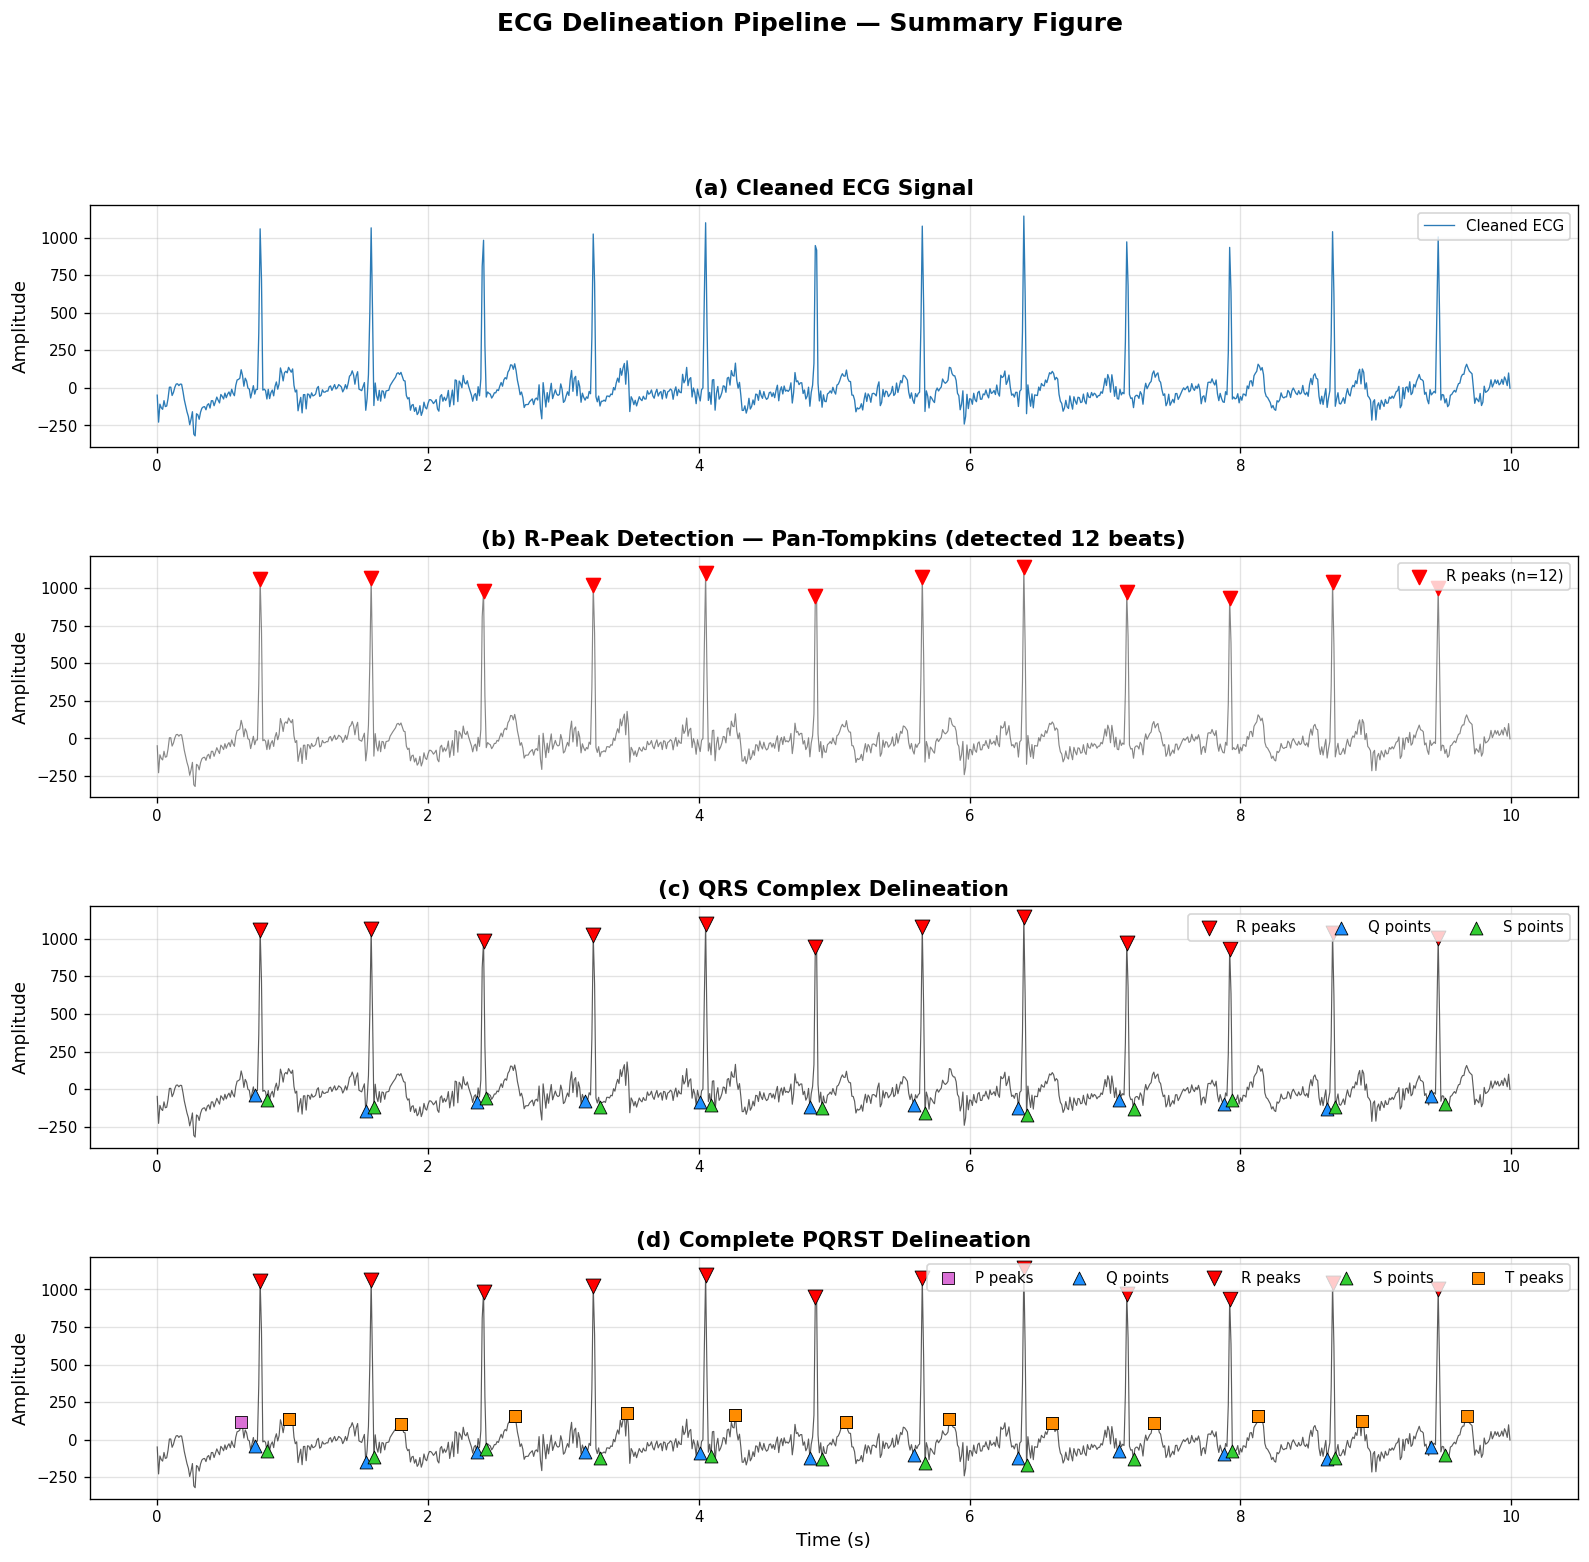

Figure saved: ecg_delineation_summary.pdf


In [119]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 31 — Publication-Quality 4-Panel Summary Figure
# Combines all pipeline stages in one figure suitable for a research report.
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 14))
gs  = fig.add_gridspec(4, 1, hspace=0.45)

# ── Panel 1: Cleaned ECG ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(time_axis, ecg_clean, color='#2c7bb6', linewidth=0.8, label='Cleaned ECG')
ax1.set_title('(a) Cleaned ECG Signal', fontweight='bold')
ax1.set_ylabel('Amplitude')
ax1.legend(loc='upper right')
ax1.grid(True)

# ── Panel 2: R-peak detection ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(time_axis, ecg_clean, color='#555555', linewidth=0.7, alpha=0.7)
if len(r_peaks) > 0:
    ax2.scatter(r_peaks / FS, ecg_clean[r_peaks],
                color='red', s=70, zorder=5, label=f'R peaks (n={len(r_peaks)})', marker='v')
ax2.set_title(f'(b) R-Peak Detection — Pan-Tompkins (detected {len(r_peaks)} beats)', fontweight='bold')
ax2.set_ylabel('Amplitude')
ax2.legend(loc='upper right')
ax2.grid(True)

# ── Panel 3: QRS delineation ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(time_axis, ecg_clean, color='#333333', linewidth=0.7, alpha=0.8)
scatter_peaks(ax3, r_peaks, ecg_clean, time_axis, 'R')
scatter_peaks(ax3, q_peaks, ecg_clean, time_axis, 'Q')
scatter_peaks(ax3, s_peaks, ecg_clean, time_axis, 'S')
ax3.set_title('(c) QRS Complex Delineation', fontweight='bold')
ax3.set_ylabel('Amplitude')
ax3.legend(loc='upper right', ncol=3)
ax3.grid(True)

# ── Panel 4: Full PQRST ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3])
ax4.plot(time_axis, ecg_clean, color='#333333', linewidth=0.7, alpha=0.8)
scatter_peaks(ax4, p_peaks, ecg_clean, time_axis, 'P')
scatter_peaks(ax4, q_peaks, ecg_clean, time_axis, 'Q')
scatter_peaks(ax4, r_peaks, ecg_clean, time_axis, 'R')
scatter_peaks(ax4, s_peaks, ecg_clean, time_axis, 'S')
scatter_peaks(ax4, t_peaks, ecg_clean, time_axis, 'T')
ax4.set_title('(d) Complete PQRST Delineation', fontweight='bold')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Amplitude')
ax4.legend(loc='upper right', ncol=5)
ax4.grid(True)

fig.suptitle('ECG Delineation Pipeline — Summary Figure', fontsize=15, fontweight='bold', y=0.995)
plt.savefig('ecg_delineation_summary.pdf', bbox_inches='tight')
plt.show()
print("Figure saved: ecg_delineation_summary.pdf")


## Cell 32 — Final Delineation Pipeline Report


In [120]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 32 — Final Pipeline Report
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "═" * 65)
print("  FINAL REPORT — ECG PEAK DETECTION & PQRST DELINEATION")
print("═" * 65)

print(f"\n  ▸ Input Signal")
print(f"    Source          : ecg_bandpassed (preprocessing output)")
print(f"    Sampling rate   : {FS} Hz")
print(f"    Duration        : {N/FS:.2f} s  ({N} samples)")

print(f"\n  ▸ Pan-Tompkins R-Peak Detection")
print(f"    Derivative kernel     : [-1, -2, 0, 2, 1] / 8  (Pan & Tompkins, 1985)")
print(f"    Integration window    : {W_int} samples  ({W_int/FS*1000:.0f} ms)")
print(f"    Detection threshold   : {THRESHOLD_FRACTION*100:.0f}% of integrated peak")
print(f"    Refractory period     : {MIN_RR_DISTANCE_S*1000:.0f} ms")
print(f"    R peaks detected      : {len(r_peaks)}")

print(f"\n  ▸ QRS Delineation")
print(f"    Q search window : [{Q_SEARCH_BEFORE_S*1000:.0f}, {Q_SEARCH_BEFORE_E*1000:.0f}] ms before R")
print(f"    S search window : [{S_SEARCH_AFTER_S*1000:.0f}, {S_SEARCH_AFTER_E*1000:.0f}] ms after R")
print(f"    Q peaks         : {len(q_valid)} / {len(r_peaks)}")
print(f"    S peaks         : {len(s_valid)} / {len(r_peaks)}")

print(f"\n  ▸ P/T Detection")
print(f"    P search window : {P_AFTER_PREV_R*1000:.0f}–{P_BEFORE_R_END*1000:.0f} ms before R")
print(f"    T search window : {T_AFTER_S_START*1000:.0f}–{T_AFTER_S_MAX*1000:.0f} ms after S")
print(f"    P peaks         : {len(p_valid)} / {len(r_peaks)}")
print(f"    T peaks         : {len(t_valid)} / {len(r_peaks)}")

if len(rr_intervals) > 0:
    print(f"\n  ▸ Heart Rate & HRV")
    print(f"    Mean HR         : {np.nanmean(hr_bpm):.1f} BPM")
    print(f"    Mean RR         : {np.nanmean(rr_ms):.1f} ms")
    print(f"    SDNN            : {std_rr:.2f} ms")
    print(f"    RMSSD           : {rmssd:.2f} ms")
    print(f"    pNN50           : {pnn50:.1f} %")

print(f"\n  ▸ Validation")
print(f"    Checks passed   : {len(passed_list)}")
print(f"    Warnings issued : {len(warnings_list)}")

print(f"\n  ▸ Output Figures")
print(f"    pt_pipeline_stages.pdf     — Pan-Tompkins 4-stage transformation")
print(f"    r_peak_detection.pdf       — R-peak detection with threshold")
print(f"    qrs_delineation.pdf        — Q, R, S markers")
print(f"    pqrst_delineation.pdf      — Full PQRST overlay")
print(f"    single_beat_zoom.pdf       — Single-beat anatomy")
print(f"    rr_tachogram.pdf           — Beat-to-beat variability")
print(f"    ecg_delineation_summary.pdf — 4-panel publication figure")

print(f"\n  ▸ Extension Points (Future Work)")
print(f"    ✗  Arrhythmia classification  — extend with rule-based or ML classifier")
print(f"    ✗  Onset/offset detection     — morphology-based QRS onset, T-wave end")
print(f"    ✗  Frequency-domain HRV       — requires ≥ 5 min recording (LF/HF ratio)")
print(f"    ✗  Multi-lead fusion          — extend for 12-lead ECG")
print(f"    ✗  Real-time streaming        — extend with circular buffer + live plot")

print("\n" + "═" * 65)



═════════════════════════════════════════════════════════════════
  FINAL REPORT — ECG PEAK DETECTION & PQRST DELINEATION
═════════════════════════════════════════════════════════════════

  ▸ Input Signal
    Source          : ecg_bandpassed (preprocessing output)
    Sampling rate   : 100 Hz
    Duration        : 10.00 s  (1000 samples)

  ▸ Pan-Tompkins R-Peak Detection
    Derivative kernel     : [-1, -2, 0, 2, 1] / 8  (Pan & Tompkins, 1985)
    Integration window    : 15 samples  (150 ms)
    Detection threshold   : 40% of integrated peak
    Refractory period     : 200 ms
    R peaks detected      : 12

  ▸ QRS Delineation
    Q search window : [5, 60] ms before R
    S search window : [5, 60] ms after R
    Q peaks         : 12 / 12
    S peaks         : 12 / 12

  ▸ P/T Detection
    P search window : 200–80 ms before R
    T search window : 20–400 ms after S
    P peaks         : 12 / 12
    T peaks         : 12 / 12

  ▸ Heart Rate & HRV
    Mean HR         : 76.0 BPM
    Me